23/3/26

# Laser OFF Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Import

In [99]:
import time
import matplotlib.pyplot as plt
import datetime

In [2]:
from qcodes.parameters import MultiParameter
import numpy as np
from qcodes import Parameter
import sys
from time import sleep
import pyvisa
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")

from time import sleep, monotonic

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 4


# Instruments

In [796]:
yoko.close()
from qcodes.instrument_drivers.yokogawa import GS200
yoko = GS200.GS200('yoko', 'TCPIP0::10.196.52.75::inst0::INSTR')

Connected to: YOKOGAWA GS210 (serial:91T928105, firmware:2.02) in 0.05s


In [4]:
# dmm.close()
from qcodes.instrument_drivers.Keysight import Keysight34410A
dmm = Keysight34410A('dmm', 'TCPIP0::10.196.52.73::inst0::INSTR')

Connected to: Agilent Technologies 34410A (serial:MY47027892, firmware:2.35-2.35-0.09-46-09) in 0.06s


In [5]:
import BFTC
ADDRESS = '192.168.1.2:5001'
tc = BFTC.BFTC(ADDRESS)

In [725]:
from MSO5 import MSO5
MS.close()
MS = MSO5('MS', address='TCPIP0::10.196.52.96::inst0::INSTR', channels_n =4)

In [20]:
my_instrument = rm.open_resource('TCPIP0::10.141.24.83::inst0::INSTR')
print(my_instrument.query('*IDN?'))

NameError: name 'rm' is not defined

In [783]:
from Thorlabs_PM100 import Thorlabs_PM100USB 
powermeter.close()
powermeter = Thorlabs_PM100USB(name='powermeter', address='USB0::0x1313::0x8072::1906768::0::INSTR')

[powermeter(Thorlabs_PM100USB)] Error getting or interpreting *IDN?: ''
Traceback (most recent call last):
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 100, in get_idn
    idstr = self.ask("*IDN?")
            ^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 445, in ask
    raise e
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 439, in ask
    answer = self.ask_raw(cmd)
             ^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\visa.py", line 392, in ask_raw
    response = self.visa_handle.query(cmd)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\pyvisa\resources\messagebased.py", line 690, in query
    return self.read()
           ^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\pyvisa\resources\messagebased.py", line 519, in read
    message = self._

In [784]:
from Thorlabs_PM100 import Thorlabs_S120
pm120.close()
pm120 = Thorlabs_S120(name='pm120', address='USB0::0x1313::0x8072::1913782::0::INSTR')

In [21]:
rm = pyvisa.ResourceManager()

In [22]:
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL5::INSTR',
 'ASRL6::INSTR',
 'ASRL7::INSTR',
 'ASRL8::INSTR',
 'ASRL9::INSTR',
 'ASRL10::INSTR',
 'ASRL11::INSTR',
 'ASRL12::INSTR',
 'ASRL13::INSTR',
 'TCPIP0::10.196.50.27::inst0::INSTR',
 'USB0::0x1313::0x8072::1906768::0::INSTR',
 'USB0::0x1313::0x8072::1913782::0::INSTR',
 'TCPIP0::10.196.52.75::inst0::INSTR',
 'TCPIP0::10.196.52.73::inst0::INSTR',
 'TCPIP0::10.196.52.96::inst0::INSTR')

In [251]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL5::INSTR',
 'ASRL6::INSTR',
 'ASRL7::INSTR',
 'ASRL8::INSTR',
 'ASRL9::INSTR',
 'ASRL10::INSTR',
 'ASRL11::INSTR',
 'ASRL12::INSTR',
 'ASRL13::INSTR',
 'TCPIP0::10.196.50.27::inst0::INSTR',
 'USB0::0x1313::0x8072::1906768::0::INSTR',
 'USB0::0x1313::0x8072::1913782::0::INSTR',
 'TCPIP0::10.196.52.75::inst0::INSTR',
 'TCPIP0::10.196.52.73::inst0::INSTR',
 'TCPIP0::10.196.52.96::inst0::INSTR',
 'USB0::0x05E6::0x2230::9010428::0::INSTR')

In [10]:
import PPCL550
laser = PPCL550.PPCL550(name='laser', address='ASRL13')

D:\SNSPD\SNSPD2\PPCL550.py:4: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import create_on_off_val_mapping


Connected to: PurePhotonic PPCL550 (serial:PP70AJ005, firmware:PV 2.0.0:HW 3.0.0:FW 7.0.0:AS C1:OT 1.0.0) in 1.58s


In [786]:
yoko.close()

In [788]:
powermeter.close()

In [790]:
pm120.close()

In [792]:
tc.close()

AttributeError: 'BFTC' object has no attribute 'close'

In [ ]:
'USB0::0x05E6::0x2230::9010428::0::INSTR'

In [252]:
from qcodes.instrument_drivers.yokogawa import GS200
import inspect 


In [253]:
inspect.getsourcefile(GS200)

'C:\\Users\\QNL\\anaconda3\\Lib\\site-packages\\qcodes\\instrument_drivers\\yokogawa\\GS200.py'

In [711]:
from qcodes.instrument_drivers.Keithley import Keithley_2000
p_att.close()
p_att = Keithley_2000.Keithley2000('p_att', 'USB0::0x05E6::0x2230::9010428::0::INSTR')

Connected to: Keithley instruments 2230G-30-1 (serial:9010428, firmware:1.16-1.04) in 0.13s


In [268]:
p_att.write('*IDN?'))

None


In [794]:
yoko.close()

In [712]:
p_att.write('VOLT 0')

# Laser Calibration Code

In [ ]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [ ]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



# Critical Current

In [9]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(0.1e-6, 4.1e-6, 0.1e-6)


print('Old Device Line 2')
print('Ramp up')
ramp_up = np.arange(0, currents[0], 0.5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Old Device Line 2
Ramp up
Starting experimental run with id: 2. 
2
Start current 1e-07
Start current 2e-07
Start current 3e-07
Start current 4e-07
Start current 5e-07
Start current 6e-07
Start current 7e-07
Start current 8e-07
Start current 9e-07
Start current 1e-06
Start current 1.1e-06
Start current 1.2e-06
Start current 1.2999999999999998e-06
Start current 1.3999999999999997e-06
Start current 1.5e-06
Start current 1.6e-06
Start current 1.6999999999999998e-06
Start current 1.7999999999999997e-06
Start current 1.9e-06
Start current 2e-06
Start current 2.1e-06
Start current 2.1999999999999997e-06
Start current 2.3e-06
Start current 2.4e-06
Start current 2.4999999999999998e-06
Start current 2.5999999999999997e-06
Start current 2.6999999999999996e-06
Start current 2.8e-06
Start current 2.8999999999999998e-06
Start current 2.9999999999999997e-06
Start current 3.1e-06
Start current 3.2e-06
Start current 3.2999999999999997e-06
Start current 3.3999999999999996e-06
Start current 3.49999999999

Text(0, 0.5, 'Ratio V/I')

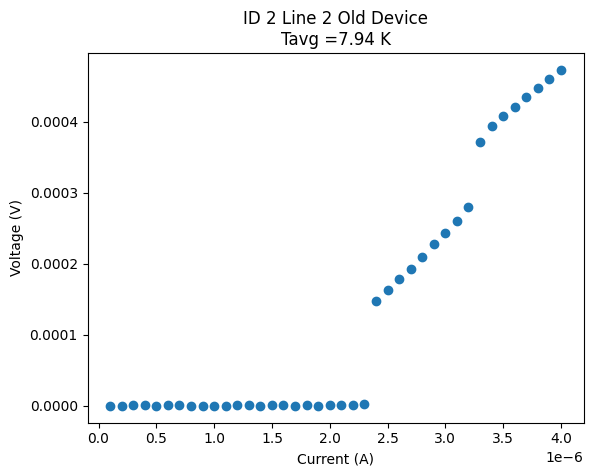

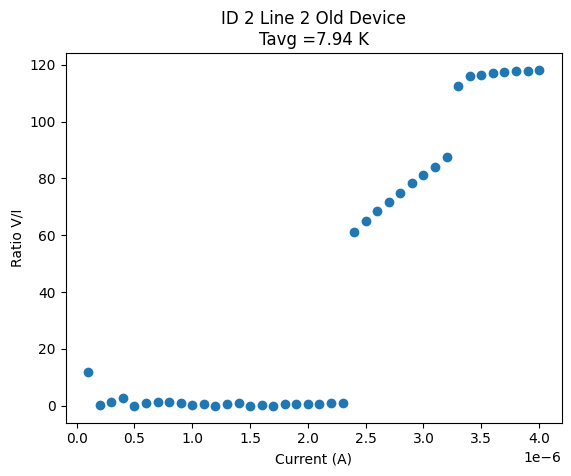

In [429]:
ID = 2
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID} {device_name_2}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID} {device_name_2}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Ratio V/I')

In [13]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(1e-6, 8e-6, 0.5e-6)


print('R7C6 Line 1')
print('Ramp up')
ramp_up = np.arange(0, currents[0], 0.5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


R7C6 Line 1
Ramp up
Starting experimental run with id: 3. 
3
Start current 1e-06
Start current 1.5e-06
Start current 2.0000000000000003e-06
Start current 2.5e-06
Start current 3e-06
Start current 3.5000000000000004e-06
Start current 4.000000000000001e-06
Start current 4.5e-06
Start current 5e-06
Start current 5.500000000000001e-06
Start current 6.000000000000001e-06
Start current 6.5000000000000004e-06
Start current 7.000000000000001e-06
Start current 7.500000000000001e-06
Ramping down
Current is 1e-06
Finished!


Text(0, 0.5, 'Ratio')

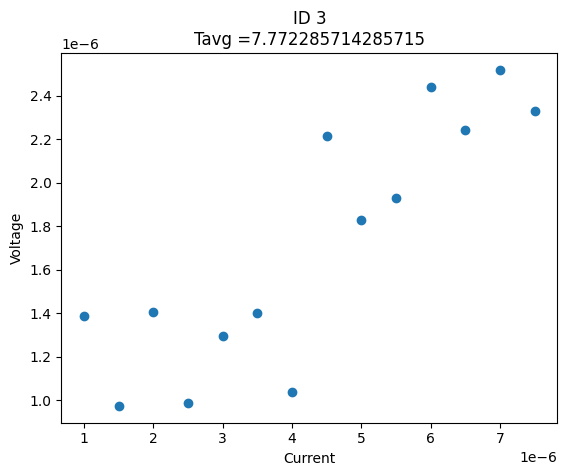

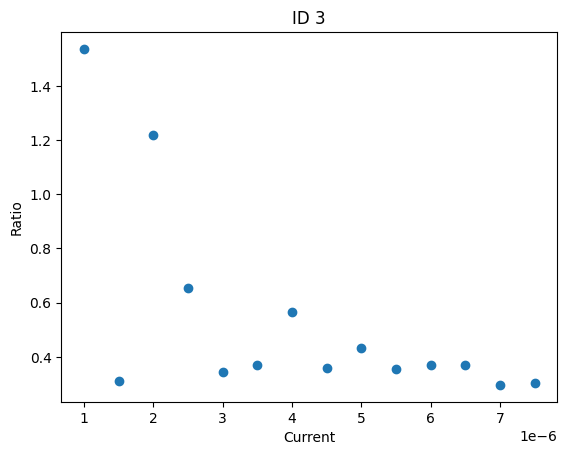

In [14]:
ID = 3
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [15]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(8e-6, 18e-6, 0.5e-6)


print('R7C6 Line 1')
print('Ramp up')
ramp_up = np.arange(0, currents[0], 0.5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


R7C6 Line 1
Ramp up
Starting experimental run with id: 4. 
4
Start current 8e-06
Start current 8.5e-06
Start current 9e-06
Start current 9.5e-06
Start current 1e-05
Start current 1.0500000000000001e-05
Start current 1.1000000000000001e-05
Start current 1.1500000000000002e-05
Start current 1.2000000000000002e-05
Start current 1.2500000000000002e-05
Start current 1.3000000000000003e-05
Start current 1.3500000000000003e-05
Start current 1.4000000000000003e-05
Start current 1.4500000000000003e-05
Start current 1.5000000000000004e-05
Start current 1.5500000000000004e-05
Start current 1.6000000000000003e-05
Start current 1.6500000000000005e-05
Start current 1.7000000000000007e-05
Start current 1.7500000000000005e-05
Start current 1.8000000000000004e-05
Ramping down
Current is 8e-06
Finished!


Text(0, 0.5, 'Ratio V/I')

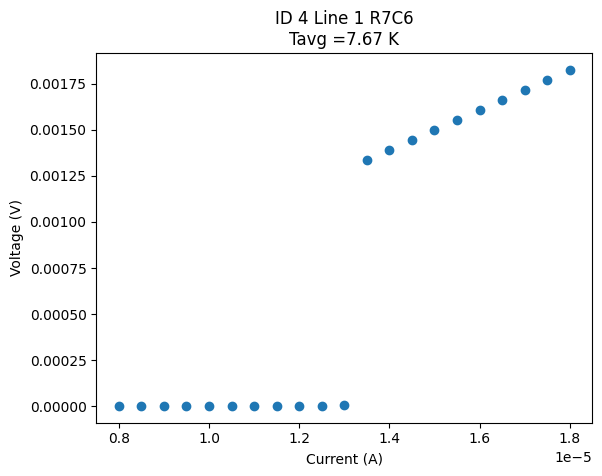

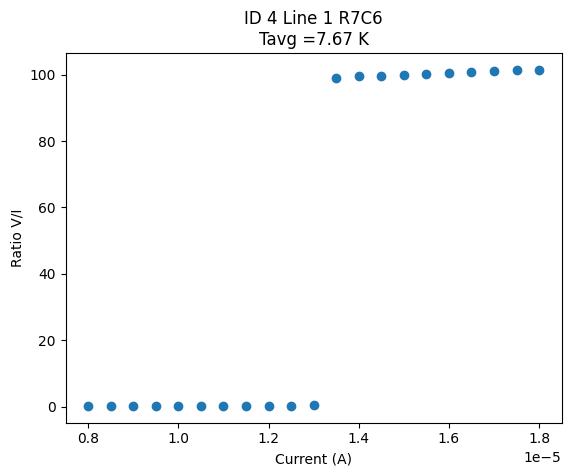

In [428]:
ID = 4
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])

plt.plot(current, voltage, 'o')
plt.title(f'ID {ID} {device_name_1}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID} {device_name_1}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Ratio V/I')

# 24/3/26

In [11]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [12]:
laser.power()

7.0

In [16]:
laser.enable(True)
print('Laser is ON')

Laser is ON


In [18]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Starting experimental run with id: 7. 
7
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;640.00E-12;181;"V";2.0000E-3;0.0E+0;15.0000E-3;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

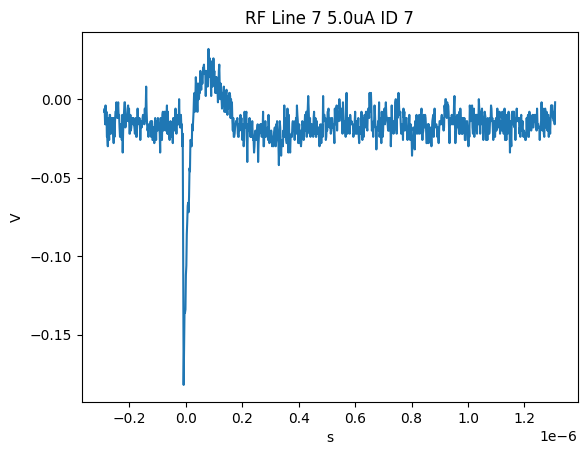

In [26]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id}')
plt.xlabel('s')
plt.ylabel('V')


peak r: [-36400.]


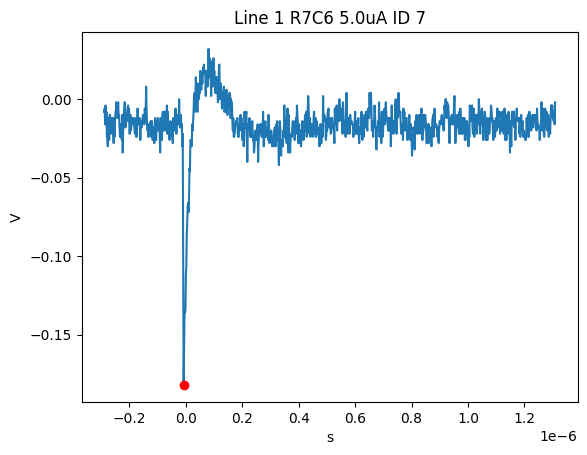

In [34]:
device_name_1 = 'Line 1 R7C6'
device_name_2 = 'Line 2 Old Device'
ID = 7

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

peak = np.where(trace == min(trace))

plt.plot(time_axis, trace)
plt.plot(time_axis[peak], trace[peak], 'ro')
plt.title(f'{device_name_1} {current*1e6}uA ID {ID}')
plt.xlabel('s')
plt.ylabel('V')



In [ ]:
v_peak = -trace[peak]
r_peak = v_peak/current

print(f'peak r: {r_peak}')

In [39]:
-v_peak

array([0.182])

In [40]:
-v_peak/current

array([36400.])

Try with laser on

In [41]:
laser.enable(True)
print('Laser is ON')

Laser is ON


In [42]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [43]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [44]:
pm120.power()

0.00484627998

In [49]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [51]:
print(f'Power: {pm120.power()}')
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(5)
print(f'Power: {pm120.power()}')

Power: 0.00484209741
Laser enable status: True
Power: 0.00485150795


In [52]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [53]:
print(f'Power: {pm120.power()}')
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(5)
print(f'Power: {pm120.power()}')

Power: 1.23248922e-09
Laser enable status: True
Power: 0.00484314281


In [63]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [55]:
print(f'Power: {pm120.power()}')
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(5)
print(f'Power: {pm120.power()}')

Power: 1.83831422e-10
Laser enable status: True
Power: 0.00485359924


Quick check on line 1

In [58]:
device_name_1

'Line 1 R7C6'

In [57]:
yoko.current()

1.25e-05

In [78]:
counts = 3e3 
window = 100e-3 

In [96]:
CR = counts/window

In [97]:
CR

30000.0

In [61]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Expected counts calculation

In [393]:
import scipy.constants as spc 


bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser =  0.00484314281/bs90
Pin = Plaser*bs10 # power reaching attenuators 

Patt_VOA1550PA = -48.5 # measurement 3 ID 15 
Patt_VOA50PM_APC = -48.5 # measurement 3 ID 16
Patt_fiber_1 = -0.558
Patt_fiber_2 = -1.044 

# Pin_dBm = 10*np.log10(Pin/1e-3) # power reaching attenuators in dBm
# Pdevice_dBm =  Pin_dBm - Patt_VOA1550PA -  Patt_VOA50PM_APC  # power reaching device in dBm
# Pdevice = 10**(Pdevice_dBm/10)

total_attenuation_fiber2 = Patt_VOA1550PA + Patt_VOA50PM_APC + Patt_fiber_2
Pdevice = Pin*(10**(total_attenuation_fiber2/10))

wavelength = 1550e-9 
f = spc.c/wavelength 
Ephoton = spc.h*f

Nphotons_fiber2 = Pdevice/Ephoton

print(f'Photons per second: {Nphotons_fiber2}')

Photons per second: 573467.1443081173


In [394]:
Plaser

0.00531158238154148

In [396]:
Pdevice

7.349428600141202e-14

In [95]:
30000.0/573467.1443081173

0.05231337191286645

In [98]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


## Dark Counts

In [101]:
n_captures = 10
bin_length = 1
# Run count 
MS.write("SEARCH:SEARCH1:STATE 0")
MS.write("SEARCH:SEARCH1:STATE 1")
MS.write("SEARCH:SEARCH2:STATE 0")
MS.write("SEARCH:SEARCH2:STATE 1")

start = time.perf_counter()
print(f'This acquisition will take {n_captures*bin_length}s')
print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

counts1= []
counts2= []


for i in range(n_captures):
    time.sleep(bin_length)

    # Extract counts 
    count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
    count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

    counts1.append(count1)
    counts2.append(count2)


# calculate total counts 
total_counts1 = sum(counts1)
total_counts2 = sum(counts2)

This acquisition will take 10s
15 27


In [103]:
total_counts2

138

In [105]:
counts2

[16, 12, 21, 11, 11, 14, 14, 11, 18, 10]

In [106]:
counts1

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [107]:
print(MS.ask('WFMOutpre?'))

1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 51.2V/div, 10ms/div, 62500000 points, Sample mode";1000000;Y;LINEAR;"s";1.60E-9;319.9999988079072E-12;11250000;"V";8.0000E-3;0.0E+0;28.0000E-3;TIME;ANALOG;0.0E+0;0.0E+0;1


In [117]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/samplerate
time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
trace_time = time_axis[-1] - time_axis[0] # time in trace

In [118]:
trace_time

np.float64(0.0999999984)

In [115]:
time_axis[-1] - time_axis[0]

np.float64(0.0999999984)

In [116]:
time_axis[-1] - time_axis[0] # time in trace 

np.float64(0.0999999984)

Note to self: could automate peak finding for currents by capturing trace data and finding peak 

In [125]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(5e-6, 13e-6, 1e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))
        

print('Finished!')

Starting experimental run with id: 10. 
10
This acquisition will take 10s
16 24
This acquisition will take 10s
16 25
This acquisition will take 10s
16 25
This acquisition will take 10s
16 25
This acquisition will take 10s
16 25
This acquisition will take 10s
16 26
This acquisition will take 10s
16 26
This acquisition will take 10s
16 26
Finished!


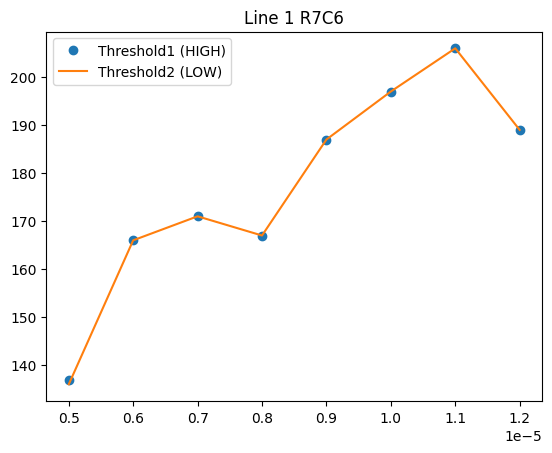

In [126]:
data = load_by_id(10).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(device_name_1)
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# follows the trend of SDCR

Light counts Device 1

In [130]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(5e-6, 13.25e-6, 0.25e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 11. 
11
Laser enable status: True
This acquisition will take 10s
16 31
This acquisition will take 10s
16 31
This acquisition will take 10s
16 31
This acquisition will take 10s
16 31
This acquisition will take 10s
16 32
This acquisition will take 10s
16 32
This acquisition will take 10s
16 32
This acquisition will take 10s
16 32
This acquisition will take 10s
16 33
This acquisition will take 10s
16 33
This acquisition will take 10s
16 33
This acquisition will take 10s
16 33
This acquisition will take 10s
16 34
This acquisition will take 10s
16 34
This acquisition will take 10s
16 34
This acquisition will take 10s
16 34
This acquisition will take 10s
16 35
This acquisition will take 10s
16 35
This acquisition will take 10s
16 35
This acquisition will take 10s
16 35
This acquisition will take 10s
16 36
This acquisition will take 10s
16 36
This acquisition will take 10s
16 36
This acquisition will take 10s
16 36
This acquisition will take 10s
16 37
This a

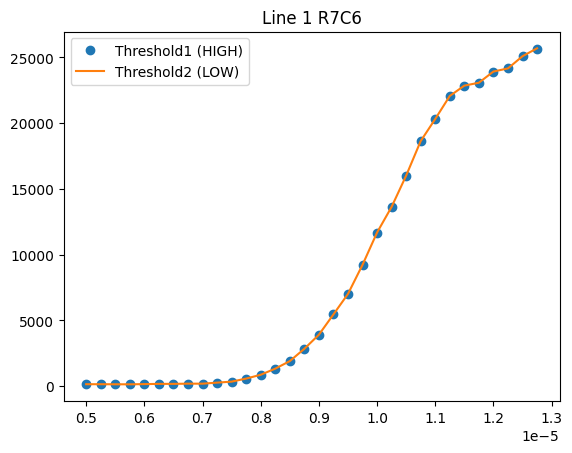

In [131]:
data = load_by_id(11).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(device_name_1)
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# follows the trend of SDCR

In [132]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(6e-6, 14.25e-6, 0.25e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 12. 
12
Laser enable status: True
This acquisition will take 10s
16 46
This acquisition will take 10s
16 47
This acquisition will take 10s
16 47
This acquisition will take 10s
16 47
This acquisition will take 10s
16 47
This acquisition will take 10s
16 48
This acquisition will take 10s
16 48
This acquisition will take 10s
16 48
This acquisition will take 10s
16 48
This acquisition will take 10s
16 49
This acquisition will take 10s
16 49
This acquisition will take 10s
16 49
This acquisition will take 10s
16 49
This acquisition will take 10s
16 50
This acquisition will take 10s
16 50
This acquisition will take 10s
16 50
This acquisition will take 10s
16 50
This acquisition will take 10s
16 51
This acquisition will take 10s
16 51
This acquisition will take 10s
16 51
This acquisition will take 10s
16 51
This acquisition will take 10s
16 52
This acquisition will take 10s
16 52
This acquisition will take 10s
16 52
This acquisition will take 10s
16 52
This a

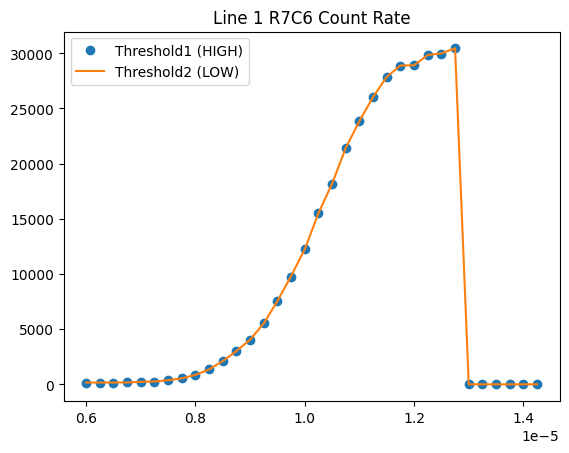

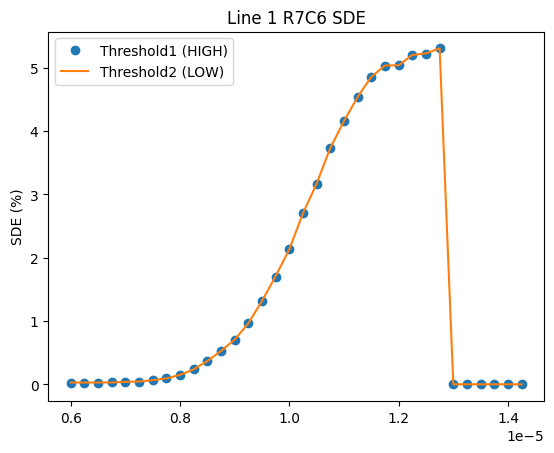

In [137]:
data = load_by_id(12).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_1} Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

plt.figure()
Nphotons_fiber2 = 573467.1443081173
plt.title(f'{device_name_1} SDE')
plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
plt.plot(current, 100*CR2/Nphotons_fiber2)
plt.ylabel('SDE (%)')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])



In [135]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [136]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(6e-6, 14.25e-6, 0.25e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 13. 
13
This acquisition will take 10s
17 5
This acquisition will take 10s
17 5
This acquisition will take 10s
17 6
This acquisition will take 10s
17 6
This acquisition will take 10s
17 6
This acquisition will take 10s
17 6
This acquisition will take 10s
17 7
This acquisition will take 10s
17 7
This acquisition will take 10s
17 7
This acquisition will take 10s
17 7
This acquisition will take 10s
17 8
This acquisition will take 10s
17 8
This acquisition will take 10s
17 8
This acquisition will take 10s
17 8
This acquisition will take 10s
17 9
This acquisition will take 10s
17 9
This acquisition will take 10s
17 9
This acquisition will take 10s
17 9
This acquisition will take 10s
17 10
This acquisition will take 10s
17 10
This acquisition will take 10s
17 10
This acquisition will take 10s
17 10
This acquisition will take 10s
17 11
This acquisition will take 10s
17 11
This acquisition will take 10s
17 11
This acquisition will take 10s
17 11
This acquisit

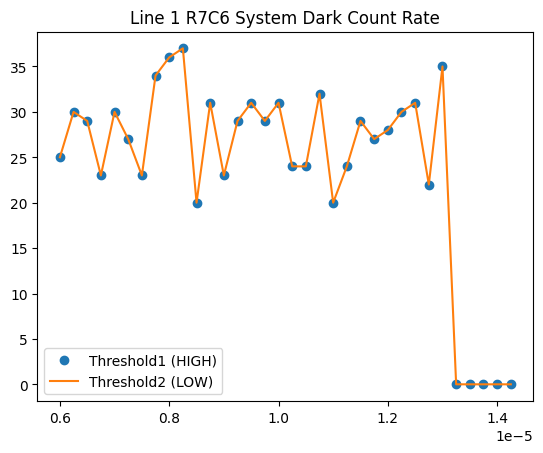

In [138]:
data = load_by_id(13).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_1} System Dark Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])



In [139]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0e-6, 14.25e-6, 0.25e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 14. 
14
This acquisition will take 10s
17 23
This acquisition will take 10s
17 24
This acquisition will take 10s
17 24
This acquisition will take 10s
17 24
This acquisition will take 10s
17 24
This acquisition will take 10s
17 25
This acquisition will take 10s
17 25
This acquisition will take 10s
17 25
This acquisition will take 10s
17 25
This acquisition will take 10s
17 26
This acquisition will take 10s
17 26
This acquisition will take 10s
17 26
This acquisition will take 10s
17 26
This acquisition will take 10s
17 27
This acquisition will take 10s
17 27
This acquisition will take 10s
17 27
This acquisition will take 10s
17 27
This acquisition will take 10s
17 28
This acquisition will take 10s
17 28
This acquisition will take 10s
17 28
This acquisition will take 10s
17 28
This acquisition will take 10s
17 29
This acquisition will take 10s
17 29
This acquisition will take 10s
17 29
This acquisition will take 10s
17 29
This acquisition will take 10s
1

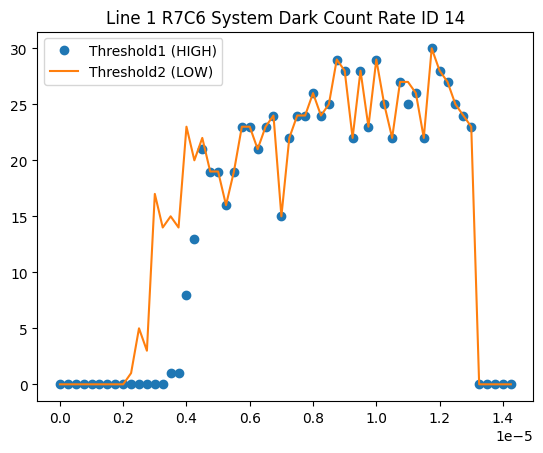

In [650]:
data = load_by_id(14).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_1} System Dark Count Rate ID 14')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

In [141]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Device 2

In [143]:
np.arange(0.5, 2.6e-6, 0.25e-6)

array([], dtype=float64)

In [147]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0.5e-6, 2.6e-6, 0.05e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 2e-6:
            threshold1 = -33.75e-3 # in volts
            threshold2 = -4e-3 # in volt
  

        elif current > 1.5e-6:
            threshold1 = -11.7e-3 # in volts
            threshold2 = -6e-3 # in volt


        else:
            threshold1 = -8.1e-3 # in volts
            threshold2 = -6e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 17. 
17
This acquisition will take 10s
18 20
This acquisition will take 10s
18 21
This acquisition will take 10s
18 21
This acquisition will take 10s
18 21
This acquisition will take 10s
18 21
This acquisition will take 10s
18 22
This acquisition will take 10s
18 22
This acquisition will take 10s
18 22
This acquisition will take 10s
18 22
This acquisition will take 10s
18 23
This acquisition will take 10s
18 23
This acquisition will take 10s
18 23
This acquisition will take 10s
18 23
This acquisition will take 10s
18 24
This acquisition will take 10s
18 24
This acquisition will take 10s
18 24
This acquisition will take 10s
18 24
This acquisition will take 10s
18 25
This acquisition will take 10s
18 25
This acquisition will take 10s
18 25
This acquisition will take 10s
18 25
This acquisition will take 10s
18 26
This acquisition will take 10s
18 26
This acquisition will take 10s
18 26
This acquisition will take 10s
18 26
This acquisition will take 10s
1

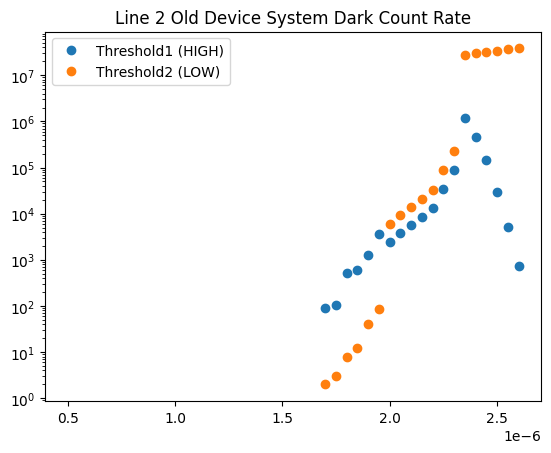

In [175]:
data = load_by_id(17).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_2} System Dark Count Rate')
plt.semilogy(current, CR1, 'o')
plt.semilogy(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

In [152]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 360
bin_length = 1 # s <-  
currents = np.arange(0.5e-6, 2.6e-6, 0.05e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 2e-6:
            threshold1 = -33.75e-3 # in volts
            threshold2 = -4e-3 # in volt
  

        elif current > 1.5e-6:
            threshold1 = -11.7e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -8.1e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 18. 
18
This acquisition will take 360s
19 47
This acquisition will take 360s
19 53
This acquisition will take 360s
19 59
This acquisition will take 360s
20 5
This acquisition will take 360s
20 11
This acquisition will take 360s
20 17
This acquisition will take 360s
20 24
This acquisition will take 360s
20 30
This acquisition will take 360s
20 36
This acquisition will take 360s
20 42
This acquisition will take 360s
20 48
This acquisition will take 360s
20 54
This acquisition will take 360s
21 0
This acquisition will take 360s
21 6
This acquisition will take 360s
21 13
This acquisition will take 360s
21 19
This acquisition will take 360s
21 25
This acquisition will take 360s
21 31
This acquisition will take 360s
21 37
This acquisition will take 360s
21 43
This acquisition will take 360s
21 49
This acquisition will take 360s
21 55
This acquisition will take 360s
22 1
This acquisition will take 360s
22 8
This acquisition will take 360s
22 14
This acquisi

In [ ]:
for i in currents[::-1]: 
    yoko.current(i)

(0.0, 100.0)

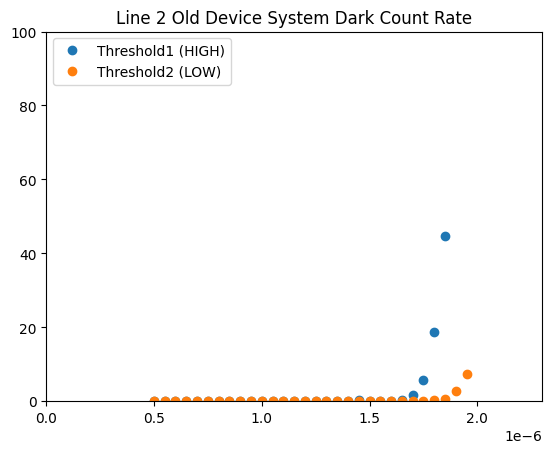

In [173]:
data = load_by_id(18).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_2} System Dark Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlim([0,2.3e-6])
plt.ylim([0,100])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

25/3/26

Vertical scale set to +/- 30, clipping 

In [164]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0, 2.6e-6, 0.2e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 2e-6:
            threshold1 = -33.75e-3 # in volts
            threshold2 = -8e-3 # in volt
  

        elif current > 1.5e-6:
            threshold1 = -11.7e-3 # in volts
            threshold2 = -6e-3 # in volt


        else:
            threshold1 = -8.1e-3 # in volts
            threshold2 = -6e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 19. 
19
This acquisition will take 10s
10 59
This acquisition will take 10s
10 59
This acquisition will take 10s
10 59
This acquisition will take 10s
11 0
This acquisition will take 10s
11 0
This acquisition will take 10s
11 0
This acquisition will take 10s
11 0
This acquisition will take 10s
11 1
This acquisition will take 10s
11 1
This acquisition will take 10s
11 1
This acquisition will take 10s
11 1
This acquisition will take 10s
11 2
This acquisition will take 10s
11 2
This acquisition will take 10s
11 2
Finished!


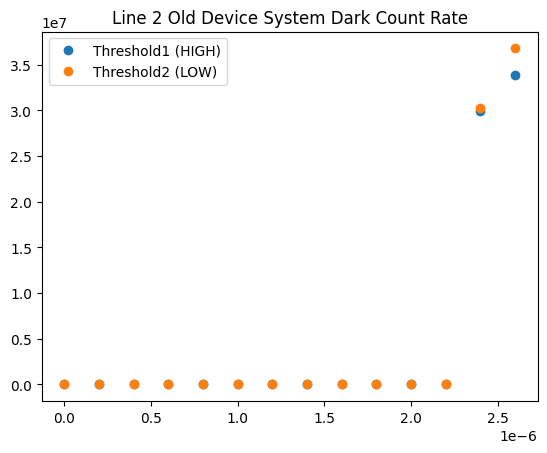

In [172]:
data = load_by_id(19).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_2} System Dark Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# plt.xlim([0,2.3e-6])
# plt.ylim([0,100])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

Thresholds adjusted

In [169]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0, 2.6e-6, 0.2e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current >= 2e-6:
            threshold1 = -24e-3 # in volts
            threshold2 = -10e-3 # in volt
  

        elif current >= 1.5e-6:
            threshold1 = -11.2e-3 # in volts
            threshold2 = -8.5e-3 # in volt


        elif current >= 1e-6: 
            threshold1 = -9e-3 
            threshold2 = -8e-3
            
        else:
            threshold1 = -6.5e-3 # in volts
            threshold2 = -4.5e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 20. 
20
This acquisition will take 10s
11 36
This acquisition will take 10s
11 36
This acquisition will take 10s
11 36
This acquisition will take 10s
11 36
This acquisition will take 10s
11 37
This acquisition will take 10s
11 37
This acquisition will take 10s
11 37
This acquisition will take 10s
11 37
This acquisition will take 10s
11 38
This acquisition will take 10s
11 38
This acquisition will take 10s
11 38
This acquisition will take 10s
11 38
This acquisition will take 10s
11 39
This acquisition will take 10s
11 39
Finished!


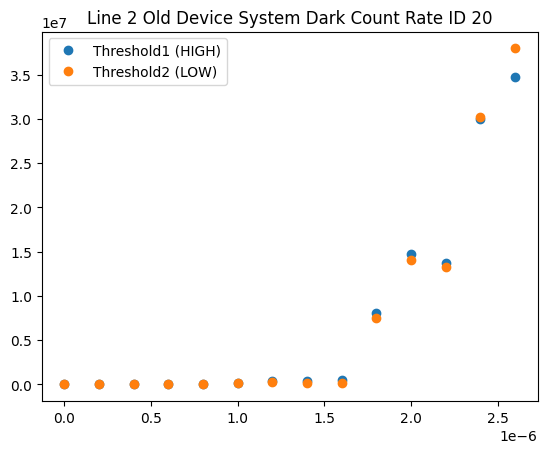

In [233]:
ID = 20
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_2} System Dark Count Rate ID {ID}')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# plt.xlim([0,2.3e-6])
# plt.ylim([0,100])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

In [234]:
meas_time

array([1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05])

In [176]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0.5e-6, 2.6e-6, 0.05e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current >= 2e-6:
            threshold1 = -24e-3 # in volts
            threshold2 = -10e-3 # in volt
  

        elif current >= 1.5e-6:
            threshold1 = -11.2e-3 # in volts
            threshold2 = -8.5e-3 # in volt


        elif current >= 1e-6: 
            threshold1 = -9e-3 
            threshold2 = -8e-3
            
        else:
            threshold1 = -6.5e-3 # in volts
            threshold2 = -4.5e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 21. 
21
This acquisition will take 10s
12 4
This acquisition will take 10s
12 5
This acquisition will take 10s
12 5
This acquisition will take 10s
12 5
This acquisition will take 10s
12 5
This acquisition will take 10s
12 6
This acquisition will take 10s
12 6
This acquisition will take 10s
12 6
This acquisition will take 10s
12 6
This acquisition will take 10s
12 7
This acquisition will take 10s
12 7
This acquisition will take 10s
12 7
This acquisition will take 10s
12 7
This acquisition will take 10s
12 8
This acquisition will take 10s
12 8
This acquisition will take 10s
12 8
This acquisition will take 10s
12 8
This acquisition will take 10s
12 9
This acquisition will take 10s
12 9
This acquisition will take 10s
12 9
This acquisition will take 10s
12 9
This acquisition will take 10s
12 10
This acquisition will take 10s
12 10
This acquisition will take 10s
12 10
This acquisition will take 10s
12 10
This acquisition will take 10s
12 11
This acquisition

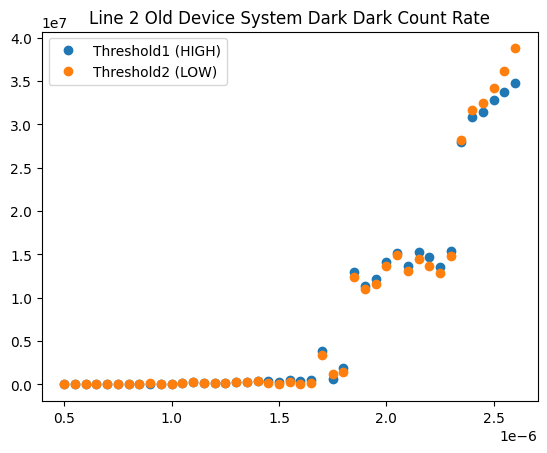

In [178]:
data = load_by_id(21).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_2} System Dark Dark Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# plt.xlim([0,2.3e-6])
# plt.ylim([0,100])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

In [179]:
trace_time

array([1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06, 1.5984e-06,
       1.5984e-06, 1.5984e-06, 1.5984e-06])

In [180]:
meas_time

array([1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05, 1.5984e-05,
       1.5984e-05, 1.5984e-05, 1.5984e-05])

Trying sweep again with longer time on the horizontal axis 

In [182]:
MS.ask('HORizontal:POSition?') 

'1.0000'

In [183]:
MS.write('HORizontal:POSition 0') 

In [184]:
MS.ask('HORizontal:POSition?') 

'0.0E+0'

In [185]:
MS.ask('HORizontal:MODe:SCAle?')

'160.0000E-9'

In [203]:
MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3

In [204]:
MS.ask('HORizontal:MODe:SCAle?')

'10.0000E-3'

In [205]:
MS.ask('HORizontal:POSition?') 

'0.0E+0'

In [206]:
# Calculate time trace 
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/samplerate
time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
trace_time = time_axis[-1] - time_axis[0] # time in trace

In [207]:
trace_time

np.float64(0.0999999984)

Checkng result running dark sweep again with longer trace length, to give 1s per data point

In [208]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0.5e-6, 2.6e-6, 0.05e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current >= 2e-6:
            threshold1 = -24e-3 # in volts
            threshold2 = -10e-3 # in volt
  

        elif current >= 1.5e-6:
            threshold1 = -11.2e-3 # in volts
            threshold2 = -8.5e-3 # in volt


        elif current >= 1e-6: 
            threshold1 = -9e-3 
            threshold2 = -8e-3
            
        else:
            threshold1 = -6.5e-3 # in volts
            threshold2 = -4.5e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 22. 
22
This acquisition will take 10s
12 45
This acquisition will take 10s
12 45
This acquisition will take 10s
12 46
This acquisition will take 10s
12 46
This acquisition will take 10s
12 46
This acquisition will take 10s
12 46
This acquisition will take 10s
12 47
This acquisition will take 10s
12 47
This acquisition will take 10s
12 47
This acquisition will take 10s
12 47
This acquisition will take 10s
12 48
This acquisition will take 10s
12 48
This acquisition will take 10s
12 48
This acquisition will take 10s
12 48
This acquisition will take 10s
12 49
This acquisition will take 10s
12 49
This acquisition will take 10s
12 49
This acquisition will take 10s
12 49
This acquisition will take 10s
12 50
This acquisition will take 10s
12 50
This acquisition will take 10s
12 50
This acquisition will take 10s
12 50
This acquisition will take 10s
12 51
This acquisition will take 10s
12 51
This acquisition will take 10s
12 51
This acquisition will take 10s
1

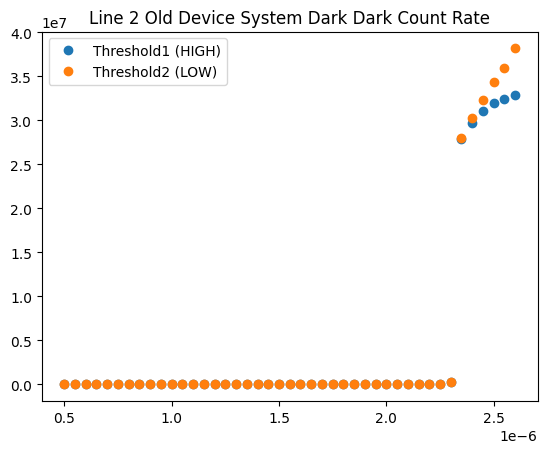

In [211]:
data = load_by_id(22).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.title(f'{device_name_2} System Dark Dark Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# plt.xlim([0,2.3e-6])
# plt.ylim([0,100])

# plt.figure()
# Nphotons_fiber2 = 573467.1443081173
# plt.title(f'{device_name_1} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

In [212]:
meas_time

array([0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998])

Light counts

In [213]:
laser.enable(True)

In [215]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [216]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True


In [218]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [219]:
laser.enable(True)

In [224]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [222]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True


In [223]:
pm120.power()

0.00485150795

No change with laser. Observed 30k counts in 100ms window with fiber port open. Testing long fiber. 

Laser -> 10% -> scerw-tightening attenuator VOA50PM_APC -48.5dB -> long fiber -> power meter 

In [231]:
import scipy.constants as spc 


bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser =  0.00484314281/bs90
Pin = Plaser*bs10 # power reaching attenuators 
 
Patt_VOA50PM_APC = -48.5   # measurement 3 ID 16


Plong_fiber = Pin*(10**(Patt_VOA50PM_APC/10))


print(f'Expected power: {Plong_fiber}')

Expected power: 6.616884821893377e-09


In [229]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:5.67092506e-09
Power on PM120 after 90% beamsplitter port is:0.00483582215
Attenuation is:49.16342711725828
Laser enable status: False


In [232]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [236]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
print(pm120.power())

Laser enable status: True
0.00447802059


In [237]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [238]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}, power 90% port: {pm120.power()}')
print(pm120.power())

Laser enable status: True
-8.65570615e-10


In [241]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [242]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}, power 90% port: {pm120.power()}')
print(pm120.power())

Laser enable status: True, power 90% port: 1.23248922e-09
1.83831422e-10


In [246]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Adding in DMM Reading

Thresholds adjusted due to change in noise floor 

In [247]:
meas = Measurement()
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0.5e-6, 2.6e-6, 0.05e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # LASER ON # 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    
    print(f'Power 90% port: {pm120.power()}')
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current >= 2e-6:
            threshold1 = -24e-3 # in volts
            threshold2 = -10e-3 # in volt
  

        elif current >= 1.5e-6:
            threshold1 = -12e-3 # in volts
            threshold2 = -8e-3 # in volt


        else: 
            threshold1 = -7e-3 
            threshold2 = -6e-3
            

        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 25. 
25
Laser enable status: True
Power 90% port: 0.00449096458
This acquisition will take 10s
14 36
This acquisition will take 10s
14 37
This acquisition will take 10s
14 37
This acquisition will take 10s
14 37
This acquisition will take 10s
14 37
This acquisition will take 10s
14 38
This acquisition will take 10s
14 38
This acquisition will take 10s
14 38
This acquisition will take 10s
14 38
This acquisition will take 10s
14 39
This acquisition will take 10s
14 39
This acquisition will take 10s
14 39
This acquisition will take 10s
14 39
This acquisition will take 10s
14 40
This acquisition will take 10s
14 40
This acquisition will take 10s
14 40
This acquisition will take 10s
14 40
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 42
This acquisition will take 10s
14 42
This acquisition will take 10s
14 42
This acquisit

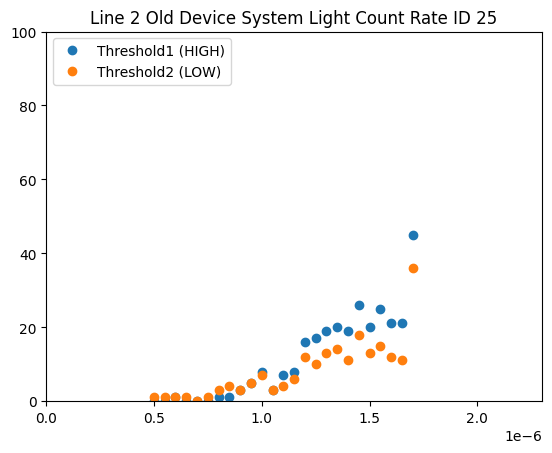

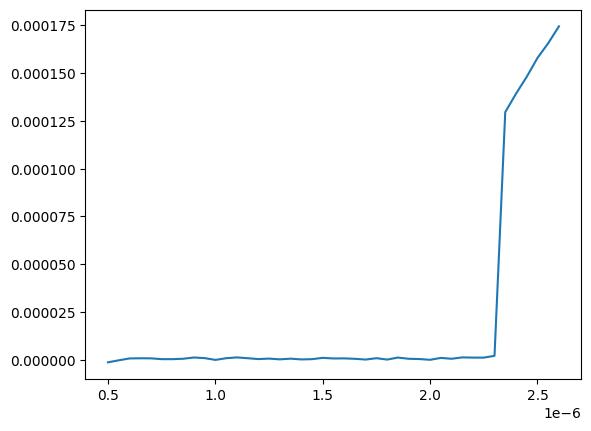

In [249]:
ID = 25
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
voltage = data['dmm_volt']['dmm_volt']

plt.title(f'{device_name_2} System Light Count Rate ID {ID}')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

plt.xlim([0,2.3e-6])
plt.ylim([0,100])

plt.figure()
plt.plot(current, voltage)


In [ ]:
import scipy.constants as spc 


bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser =  0.00484314281/bs90
Pin = Plaser*bs10 # power reaching attenuators 

Patt_VOA1550PA = -48.5 # measurement 3 ID 15 
Patt_VOA50PM_APC = -48.5 # measurement 3 ID 16
Patt_fiber_1 = -0.558

total_attenuation_fiber1 = Patt_VOA1550PA + Patt_VOA50PM_APC + Patt_fiber_1
Pdevice = Pin*(10**(total_attenuation_fiber1/10))

wavelength = 1550e-9 
f = spc.c/wavelength 
Ephoton = spc.h*f

Nphotons_fiber1 = Pdevice/Ephoton

print(f'Photons per second: {Nphotons_fiber1}')

# plt.figure()
# plt.title(f'{device_name_2} SDE')
# plt.plot(current, 100*CR1/Nphotons_fiber2, 'o')
# plt.plot(current, 100*CR2/Nphotons_fiber2)
# plt.ylabel('SDE (%)')
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])

Goal is to sweep attenuator 

In [275]:
meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")
meas.register_custom_parameter("v_attenuator", label="V")

# set voltage 
voltages = np.arange(2, 5.5, 0.5)


# extract median attenuation 
# Run a test to measure attenuation as a function of time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

for v_attenuator in voltages: 
    p_att.write(f'VOLT {v_attenuator}')
    print(v)
    time.sleep(1)

    times2 = []
    power2 = []
    power3 = []
    power = []


    bs90 = 0.9118079062146573
    bs10 = 0.08819209378534265


    print(f'Power 90% port: {pm120.power()}')

    start = time.perf_counter()

    with meas.run() as datasaver:
        print(datasaver.run_id)
        for i in range (60):
            t=i*0.5
            p1= pm120.power() # laser 
            p2 = powermeter.power() # attenuator output 
            p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
            times2.append(t)
            power2.append(p1)
            power3.append(p2) 
            power.append(p) # attenuation 
            time.sleep(0.5)

            datasaver.add_result(("times",t),
                             ("p1", p1),
                            ("p2", p2),
                            ("attenuation", p), 
                                ("v_attenuator", v_attenuator))

    end = time.perf_counter()
    print(end-start)


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('finished!')


Laser enable status: True
5
Power 90% port: 0.00485673593
Starting experimental run with id: 27. 
27
30.881484699988505
5
Power 90% port: 0.00486196438
Starting experimental run with id: 28. 
28
30.86781319999136
5
Power 90% port: 0.00487764878
Starting experimental run with id: 29. 
29
30.891863299999386
5
Power 90% port: 0.00488078548
Starting experimental run with id: 30. 
30
30.90867469999648
5
Power 90% port: 0.00485255383
Starting experimental run with id: 31. 
31
30.859227199995075
5
Power 90% port: 0.00485255383
Starting experimental run with id: 32. 
32
31.01760469999863
5
Power 90% port: 0.0048609185
Starting experimental run with id: 33. 
33
30.900552599996445
Laser enable status: False
finished!


In [ ]:
ID = 27
data = load_by_id(ID).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']
v_attenuator = data['v_attenuator']['v_attenuator'][0]

# plt.plot(times, np.multiply(p2_after_att, 1000), '.')
# plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
# plt.xlabel('Samples (approx. s)')
# plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title(f'Attenuation (VOA1550PA {v_attenuator}V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [ ]:
for ID in np.arange(27, 34):
    data = load_by_id(ID).get_parameter_data()
    times = data['times']['times']
    p1_before_att = data['p1']['p1']
    p2_after_att = data['p2']['p2']
    attenuation = data['attenuation']['attenuation']
    v_attenuator = data['v_attenuator']['v_attenuator'][0]

    # plt.plot(times, np.multiply(p2_after_att, 1000), '.')
    # plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
    # plt.xlabel('Samples (approx. s)')
    # plt.ylabel('Power (mW)')


    plt.figure()
    plt.plot(times, attenuation, '.')
    plt.title(f'Attenuation (VOA1550PA {v_attenuator}V) ID {ID}')
    plt.xlabel('Samples (approx. s)')
    plt.ylabel('Attenuation dB')

In [300]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False


Dark counts for a given bias current, sweep voltage of attenuator 

In [296]:
voltages = np.arange(3.4, 5.2, 0.2)

In [297]:
voltages[::-1]

array([5. , 4.8, 4.6, 4.4, 4.2, 4. , 3.8, 3.6, 3.4])

In [299]:
meas = Measurement()
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1 # s <-  

# set current near transition based on ID 12 
current = 12e-6

voltages = np.arange(3.4, 5.2, 0.2) # <- sweep parameter is voltage applied to attnuator

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Set attenuator to 5V
    p_att.write(f'VOLT 5')
    time.sleep(2)
    
    # LASER ON # 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    
    print(f'Power 90% port: {pm120.power()}')
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for v_attenuator in voltages[::-1]: # <- sweep voltage applied to attenuator
        
        p_att.write(f'VOLT {v_attenuator}')
        print(f'Starting V={v_attenuator}')
        time.sleep(1)
        
        
        # Set current to 12uA, before transition 
        yoko.current(current)

        # Thresholds from ID 12 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt
            

        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2), 
                             ("v_attenuator", v05_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 37. 
37
Laser enable status: True
Power 90% port: 0.00266803545
Starting V=5.000000000000002
This acquisition will take 10s
16 39
Starting V=4.800000000000001
This acquisition will take 10s
16 40
Starting V=4.600000000000001
This acquisition will take 10s
16 40
Starting V=4.4
This acquisition will take 10s
16 40
Starting V=4.200000000000001
This acquisition will take 10s
16 40
Starting V=4.0
This acquisition will take 10s
16 41
Starting V=3.8000000000000003
This acquisition will take 10s
16 41
Starting V=3.6
This acquisition will take 10s
16 41
Starting V=3.4
This acquisition will take 10s
16 42
Laser enable status: False
Finished!


Text(0, 0.5, 'Count Rate (Hz)')

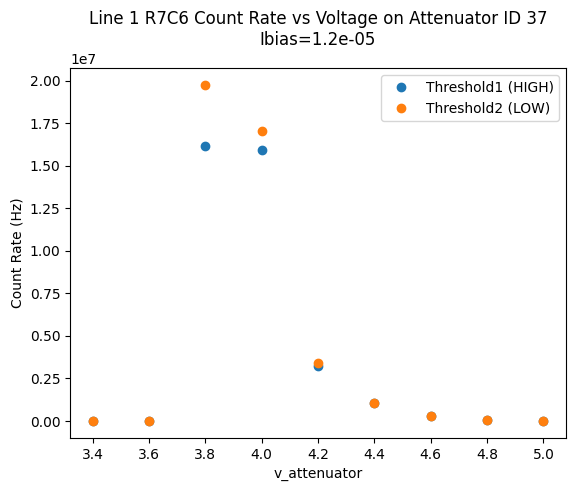

In [398]:
ID = 37
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
voltage = data['dmm_volt']['dmm_volt']
v_attenuator = data['v_attenuator']['v_attenuator']

plt.title(f'{device_name_1} Count Rate vs Voltage on Attenuator ID {ID}\nIbias={current[0]}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel('v_attenuator')
plt.ylabel('Count Rate (Hz)')

# plt.xlim([0,2.3e-6])
# plt.ylim([0,100])


Finding attenuation of each voltage in the list

In [302]:

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")
meas.register_custom_parameter("v_attenuator", label="V")
meas.register_custom_parameter("avg_attenuation", label="dB")



voltages = np.arange(3.4, 5.2, 0.2)

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

for v_attenuator in voltages: 
    p_att.write(f'VOLT {v_attenuator}')
    print(v)
    time.sleep(1)

    bs90 = 0.9118079062146573
    bs10 = 0.08819209378534265

    print(f'Power 90% port: {pm120.power()}')

    start = time.perf_counter()

    with meas.run() as datasaver:
        print(datasaver.run_id)
        for i in range (60):
            t=i*0.5
            p1= pm120.power() # laser 
            p2 = powermeter.power() # attenuator output 
            p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
            time.sleep(0.5)

            datasaver.add_result(("times",t),
                             ("p1", p1),
                            ("p2", p2),
                            ("attenuation", p), 
                                ("v_attenuator", v_attenuator),
                                ('avg_attenuation', np.average(attenuation)))

    end = time.perf_counter()
    print(end-start)


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('finished!')

Laser enable status: True
5
Power 90% port: 0.00415138993
Starting experimental run with id: 39. 
39
31.01028590000351
5
Power 90% port: 0.00414940715
Starting experimental run with id: 40. 
40
30.933797399993637
5
Power 90% port: 0.00415504351
Starting experimental run with id: 41. 
41
30.925953499987372
5
Power 90% port: 0.00415807124
Starting experimental run with id: 42. 
42
30.967396000007284
5
Power 90% port: 0.00417571282
Starting experimental run with id: 43. 
43
30.934764499994344
5
Power 90% port: 0.00416903198
Starting experimental run with id: 44. 
44
30.91539439999906
5
Power 90% port: 0.0041641253
Starting experimental run with id: 45. 
45
30.90254009999626
5
Power 90% port: 0.00417874008
Starting experimental run with id: 46. 
46
30.901066000005812
5
Power 90% port: 0.00417686068
Starting experimental run with id: 47. 
47
31.050172499992186
Laser enable status: False
finished!


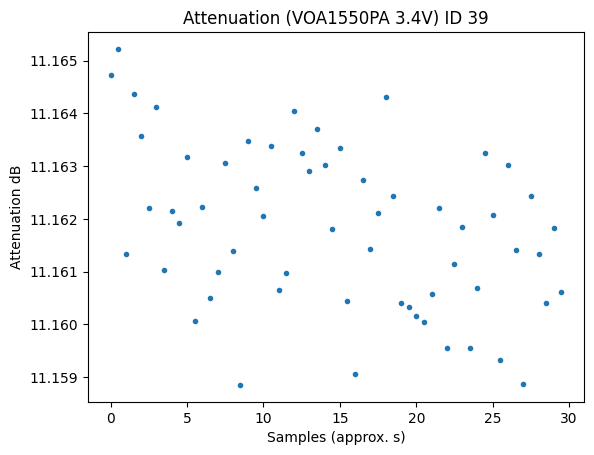

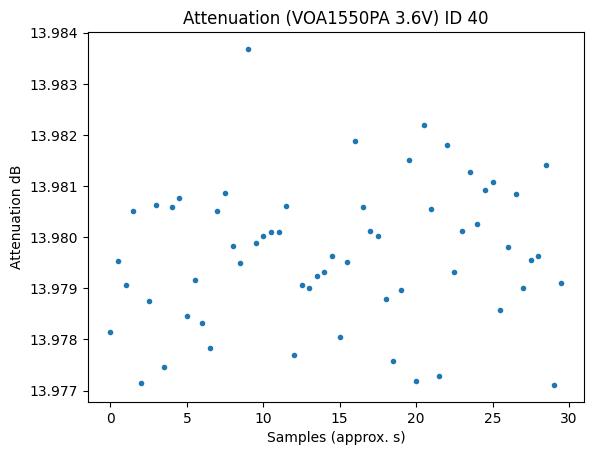

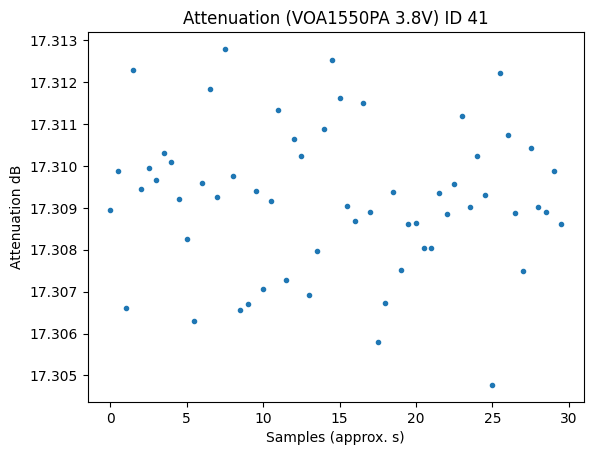

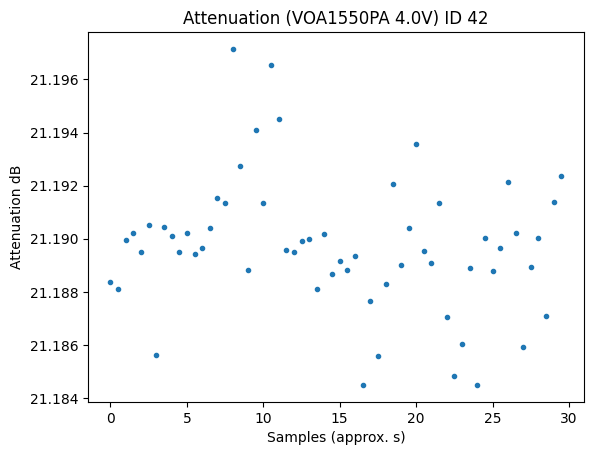

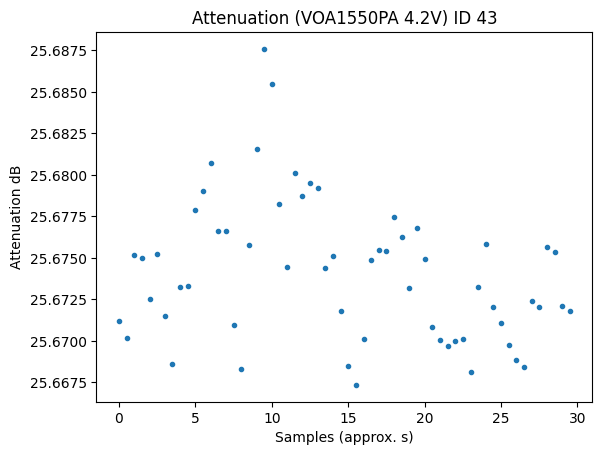

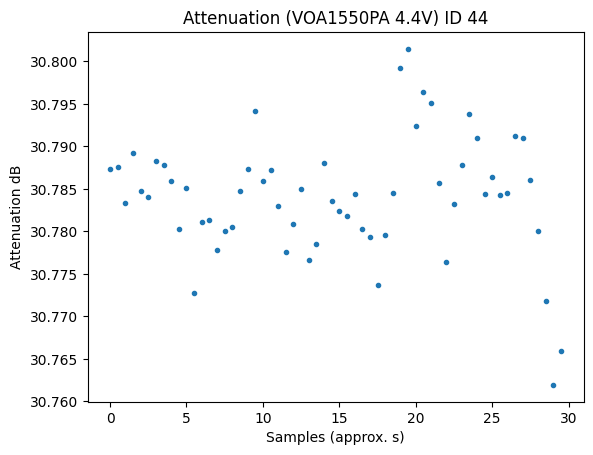

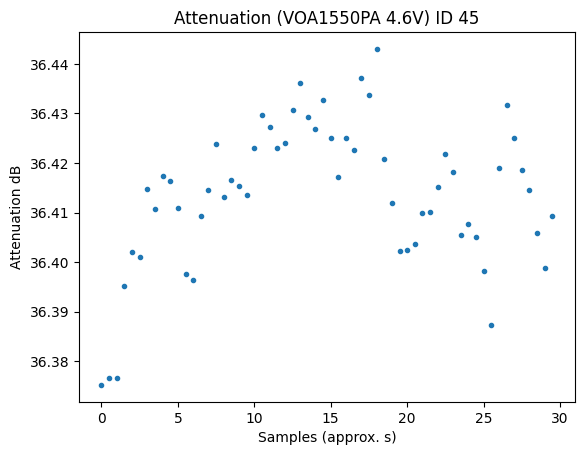

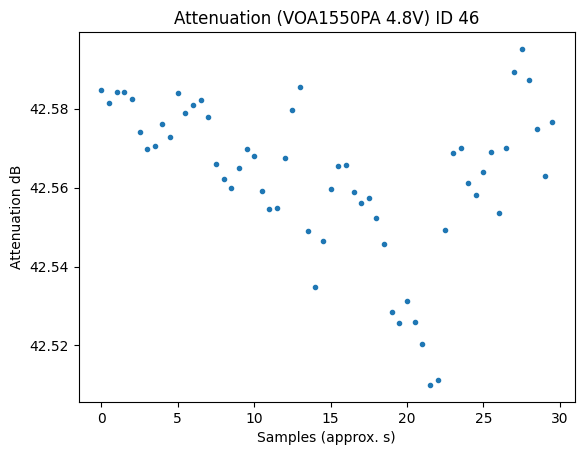

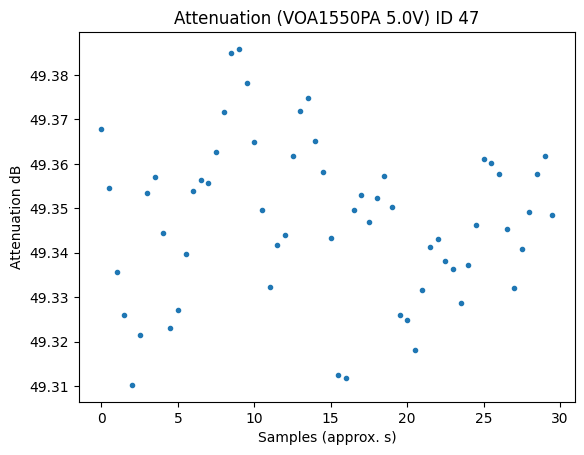

In [478]:
for ID in np.arange(39, 48):
    data = load_by_id(ID).get_parameter_data()
    times = data['times']['times']
    p1_before_att = data['p1']['p1']
    p2_after_att = data['p2']['p2']
    attenuation = data['attenuation']['attenuation']
    v_attenuator = data['v_attenuator']['v_attenuator'][0]

    # plt.plot(times, np.multiply(p2_after_att, 1000), '.')
    # plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
    # plt.xlabel('Samples (approx. s)')
    # plt.ylabel('Power (mW)')


    plt.figure()
    plt.plot(times, attenuation, '.')
    plt.title(f'Attenuation (VOA1550PA {v_attenuator}V) ID {ID}')
    plt.xlabel('Samples (approx. s)')
    plt.ylabel('Attenuation dB')

In [306]:
data = load_by_id(39).get_parameter_data()

In [308]:
data['attenuation']['attenuation']

array([11.16473116, 11.16522351, 11.16133642, 11.16436507, 11.16357342,
       11.16219855, 11.16411708, 11.1610309 , 11.16215188, 11.16192977,
       11.16316458, 11.1600618 , 11.16223298, 11.16049619, 11.16098319,
       11.16306421, 11.16139701, 11.15885082, 11.16347573, 11.16258354,
       11.162064  , 11.16338597, 11.16065863, 11.1609792 , 11.16404192,
       11.16325805, 11.1629065 , 11.16370152, 11.16301618, 11.161811  ,
       11.16333651, 11.16043972, 11.15905184, 11.16273619, 11.16143597,
       11.16211491, 11.1643096 , 11.16244146, 11.16040951, 11.16033767,
       11.16014905, 11.16005162, 11.16057236, 11.16219855, 11.15954455,
       11.16113846, 11.16184199, 11.15955225, 11.16069221, 11.16325348,
       11.16206781, 11.15931683, 11.16301693, 11.16140608, 11.15885995,
       11.16242471, 11.16133005, 11.16040219, 11.1618235 , 11.16061652])

Text(0, 0.5, 'Number of photons/sec')

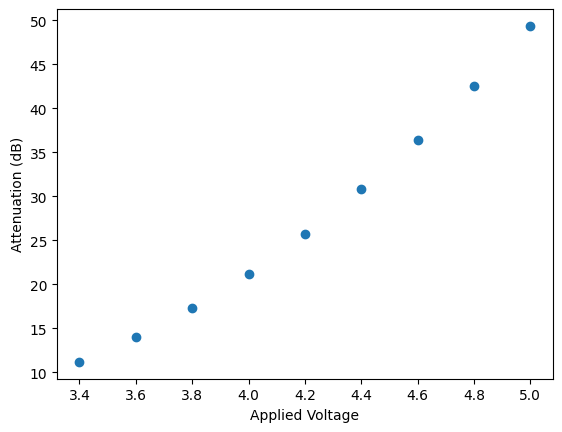

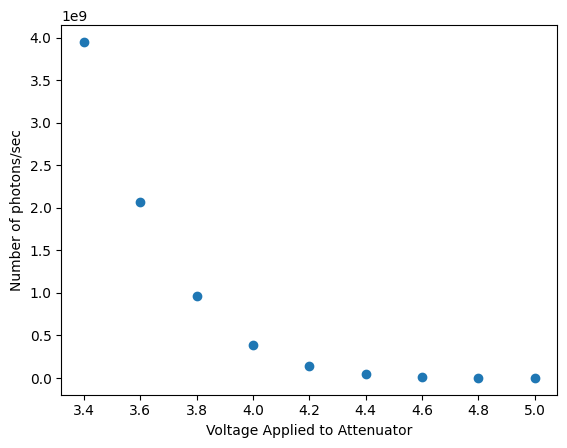

In [479]:
IDs = np.arange(39, 48)
v_applied = []
avg_att = []

for ID in IDs: 
    data = load_by_id(ID).get_parameter_data()
    avg_att.append(np.average(data['attenuation']['attenuation']))
    v_applied.append(data['v_attenuator']['v_attenuator'][0])


plt.plot(v_applied, avg_att, 'o')
plt.xlabel('Applied Voltage')
plt.ylabel('Attenuation (dB)')

import scipy.constants as spc 
wavelength = 1550e-9 
f = spc.c/wavelength 
Ephoton = spc.h*f

N_photons = []

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser =  0.00484314281/bs90
Pin = Plaser*bs10 # power reaching attenuators 

for i in avg_att: # go through values measured for average attenuation

    Patt_VOA1550PA = -i 
    Patt_VOA50PM_APC = -48.5 # measurement 3 ID 16
    # Patt_fiber_2 = -1.044 

    # Pin_dBm = 10*np.log10(Pin/1e-3) # power reaching attenuators in dBm
    # Pdevice_dBm =  Pin_dBm - Patt_VOA1550PA -  Patt_VOA50PM_APC  # power reaching device in dBm
    # Pdevice = 10**(Pdevice_dBm/10)

    total_attenuation_fiber2 = Patt_VOA1550PA + Patt_VOA50PM_APC
    Pdevice = Pin*(10**(total_attenuation_fiber2/10))

    N_photons.append(Pdevice/Ephoton)


plt.figure()
plt.plot(v_applied, N_photons, 'o')
plt.xlabel('Voltage Applied to Attenuator')
plt.ylabel('Number of photons/sec')

In [339]:
N_photons[np.where(np.array(v_applied)==4.4)[0][0]]

np.float64(43102217.75848849)

In [328]:
v_applied

[np.float64(3.4),
 np.float64(3.6),
 np.float64(3.8),
 np.float64(4.0),
 np.float64(4.2),
 np.float64(4.4),
 np.float64(4.6),
 np.float64(4.8)]

In [335]:
v_attenuator

array([5. , 4.8, 4.6, 4.4, 4.2, 4. , 3.8, 3.6, 3.4])

Text(0.5, 0, 'Voltage Applied to Attenuator (V)')

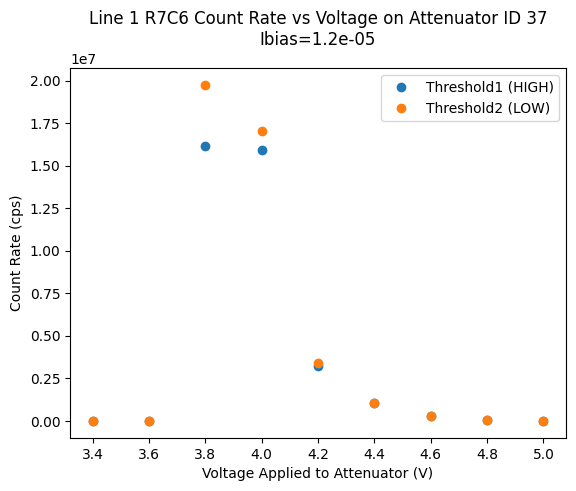

In [484]:
ID = 37
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
voltage = data['dmm_volt']['dmm_volt']
v_attenuator = data['v_attenuator']['v_attenuator']

plt.title(f'{device_name_1} Count Rate vs Voltage on Attenuator ID {ID}\nIbias={current[0]}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel('Voltage Applied to Attenuator (V)')

In [356]:
v_attenuator[1:]

array([4.8, 4.6, 4.4, 4.2, 4. , 3.8, 3.6, 3.4])

SDE at 12uA is 5.037952173722649


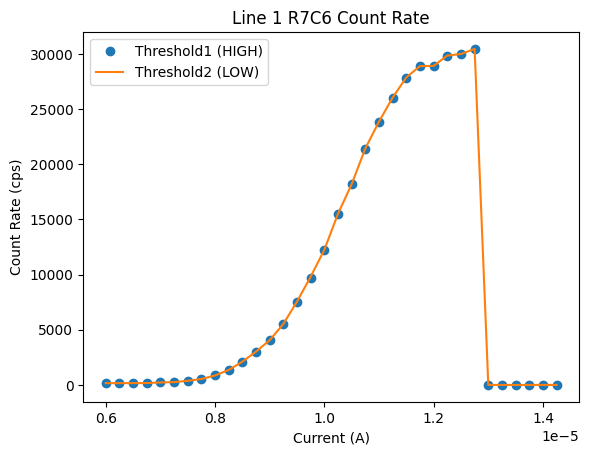

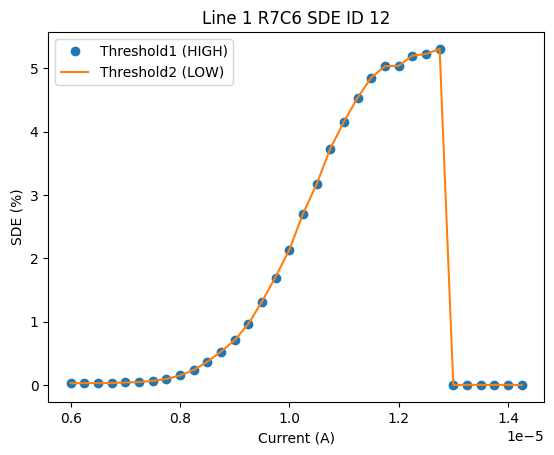

In [490]:
data = load_by_id(12).get_parameter_data()
current = data['yoko_current']['yoko_current']
# threshold1 = data['threshold1']['threshold1']
# threshold2 = data['threshold2']['threshold2']
# total_counts1 = data['total_counts1']['total_counts1'] 
# total_counts2 = data['total_counts2']['total_counts2'] 
# counts1 = data['counts1']['counts1'] 
# counts2 = data['counts2']['counts2'] 
# trace_time = data['trace_time']['trace_time']
# meas_time = data['meas_time']['meas_time']
# bin_length = data['bin_length']['bin_length']
# n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']

plt.figure()
plt.title(f'{device_name_1} Count Rate')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel('Current (A)')
plt.ylabel('Count Rate (cps)')


plt.figure()
Nphotons_fiber2 = 573467.1443081173
SDE1_perc = 100*CR1/Nphotons_fiber2
SDE2_perc = 100*CR2/Nphotons_fiber2
plt.title(f'{device_name_1} SDE ID 12')
plt.plot(current, SDE1_perc, 'o')
plt.plot(current, SDE2_perc)
plt.ylabel('SDE (%)')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel('Current (A)')


SDE_12uA_5Vappplied = SDE1_perc[np.where(np.array(current) == 12e-6)[0][0]]

print(f'SDE at 12uA is {SDE_12uA_5Vappplied}')

Text(0, 0.5, 'SDE (%)')

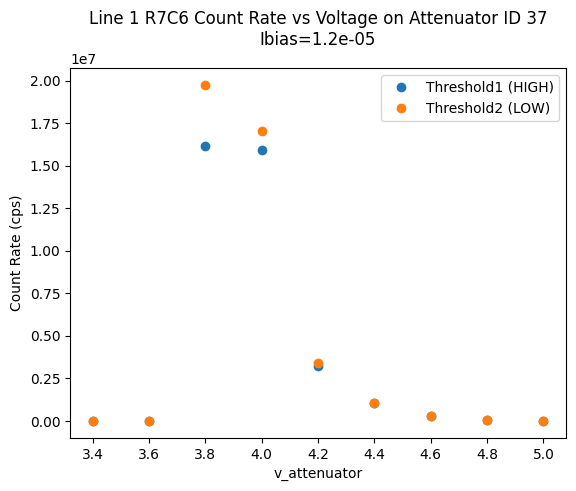

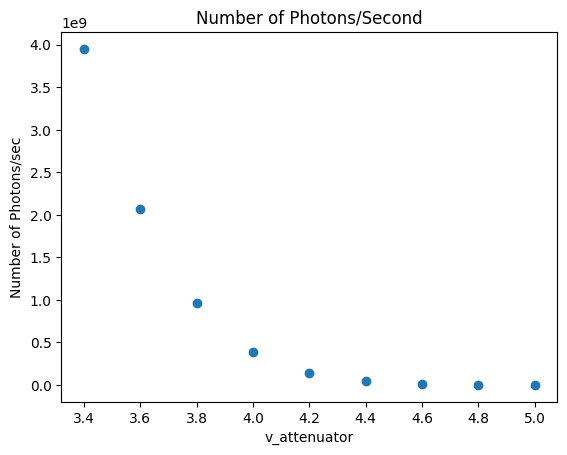

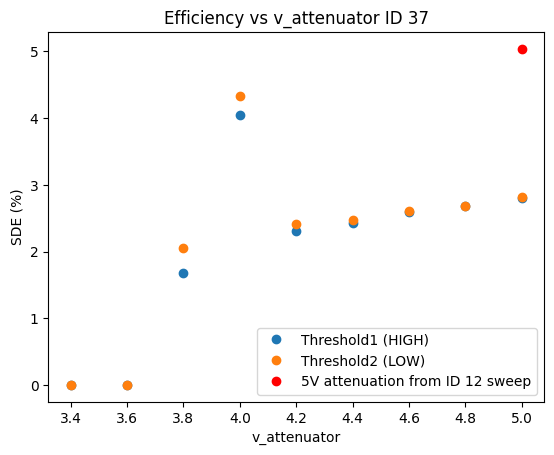

In [489]:
ID = 37
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
voltage = data['dmm_volt']['dmm_volt']
v_attenuator = data['v_attenuator']['v_attenuator']

plt.title(f'{device_name_1} Count Rate vs Voltage on Attenuator ID {ID}\nIbias={current[0]}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel('v_attenuator')
plt.ylabel('Count Rate (cps)')

plt.figure()
plt.title('Number of Photons/Second')
plt.plot(v_attenuator, N_photons[::-1], 'o') # flip number of photons to account for direction of v_attenuator sweep
plt.xlabel('v_attenuator')
plt.ylabel('Number of Photons/sec')


plt.figure()
plt.title(f'Efficiency vs v_attenuator ID {ID}')
plt.plot(v_attenuator, 100*CR1/N_photons[::-1], 'o', label='Threshold1 (HIGH)')
plt.plot(v_attenuator, 100*CR2/N_photons[::-1], 'o', label='Threshold2 (LOW)')
plt.plot(5, SDE_12uA_5Vappplied, 'ro', label='5V attenuation from ID 12 sweep')
plt.legend()
plt.xlabel('v_attenuator')
plt.ylabel('SDE (%)')

In [382]:
SDE_12uA_5Vappplied

np.float64(0.028249221284935417)

SDE at 5V attenuation with 12uA is ~5% (from ID 12 plot)  

In [372]:
CR1[np.where(np.array(v_applied) == 4.4)[0][0]]

np.float64(15900643.2544103)

In [367]:
N_photons[np.where(np.array(v_applied) == 4.4)[0][0]]

np.float64(43102217.75848849)

In [373]:
CR1[np.where(np.array(v_applied) == 4.4)[0][0]]/N_photons[np.where(np.array(v_applied) == 4.4)[0][0]]

np.float64(0.3689054550163802)

In [350]:
avg_att

[np.float64(11.161827720980925),
 np.float64(13.979658856026896),
 np.float64(17.309196060312562),
 np.float64(21.189705741441863),
 np.float64(25.67409192879833),
 np.float64(30.78408924194997),
 np.float64(36.41378359363169),
 np.float64(42.56284121377444)]

In [ ]:
ID = 37
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
voltage = data['dmm_volt']['dmm_volt']
v_attenuator = data['v_attenuator']['v_attenuator']

plt.title(f'{device_name_1} Count Rate vs Voltage on Attenuator ID {ID}\nIbias={current[0]}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])


In [322]:
N_photons[np.where(np.array(v_applied) == 4.4)[0][0]]

np.float64(392588855.23775727)

In [349]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('finished!')

Laser enable status: False
finished!


# 27/3/26

In [410]:
ID = 37
data = load_by_id(ID).get_parameter_data()
total_counts1 = data['total_counts1']['total_counts1'] 
counts1 = data['counts1']['counts1'] 
v_attenuator = data['v_attenuator']['v_attenuator']
meas_time = data['meas_time']['meas_time']

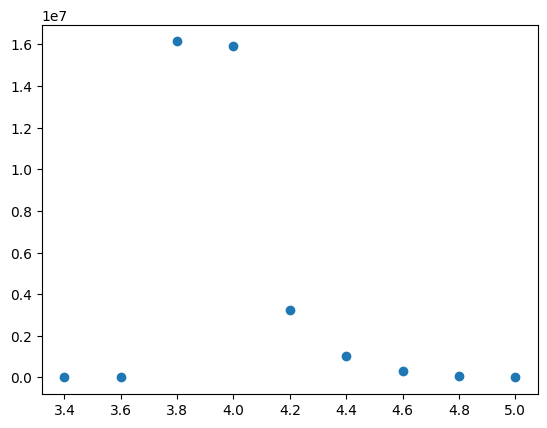

In [409]:
plt.plot(v_attenuator, total_counts1, 'o')
plt.ylabel('Total counts')

Total counts is the counts per second 

In [411]:
meas_time

array([0.99999998, 0.99999998, 0.99999998, 0.99999998, 0.99999998,
       0.99999998, 0.99999998, 0.99999998, 0.99999998])

In [405]:
counts1

array([   1646.,    1633.,    1717.,    1671.,    1653.,    1742.,
          1690.,    1657.,    1702.,    1747.,    7644.,    7667.,
          7773.,    7801.,    7639.,    7715.,    7697.,    7583.,
          7541.,    7519.,   30412.,   30624.,   30746.,   30455.,
         30616.,   30525.,   30762.,   30650.,   30768.,   30843.,
        103366.,  105228.,  104887.,  104634.,  104309.,  103928.,
        104497.,  104801.,  104673.,  105036.,  320844.,  320185.,
        321582.,  327033.,  319046.,  323748.,  326562.,  321272.,
        319960.,  326384., 1587873., 1587873., 1588070., 1592742.,
       1592742., 1589731., 1589731., 1591780., 1591780., 1588321.,
       1612114., 1612114., 1616318., 1616318., 1610533., 1610533.,
       1613454., 1613454., 1615656., 1615656.,       0.,       0.,
             0.,       0.,       0.,       0.,       0.,       0.,
             0.,       0.,       0.,       0.,       0.,       0.,
             0.,       0.,       0.,       0.,       0.,      

Device 2. Open fiber port. ~12000counts/100ms

In [412]:
12e3/100e-3

120000.0

This appears to be lower than with small attenuation values on the laser. It looks like at 4V on the attenuator, we start to see a plateau before latching. 

Single trace acquisition with fiber port open 

Starting experimental run with id: 50. 
50
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 51.2V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;480.00E-12;120;"V";8.0000E-3;0.0E+0;-40.0000E-3;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

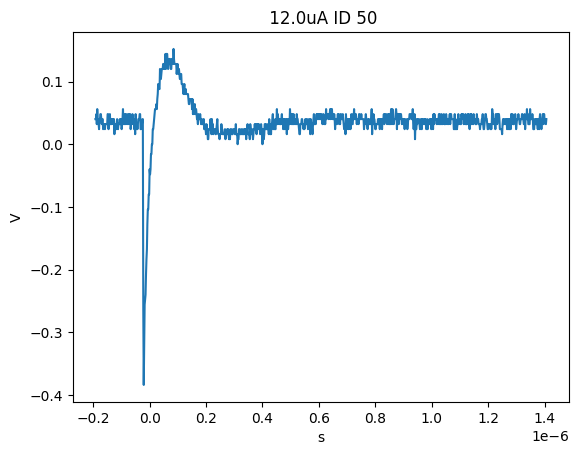

In [416]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 51. 
51
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 51.2V/div, 160ns/div, 1000 points, Sample mode";1000;Y;LINEAR;"s";1.60E-9;800.0E-12;120;"V";8.0000E-3;0.0E+0;-40.0000E-3;TIME;ANALOG;0.0E+0;0.0E+0;1
all processes finished!


Text(0, 0.5, 'V')

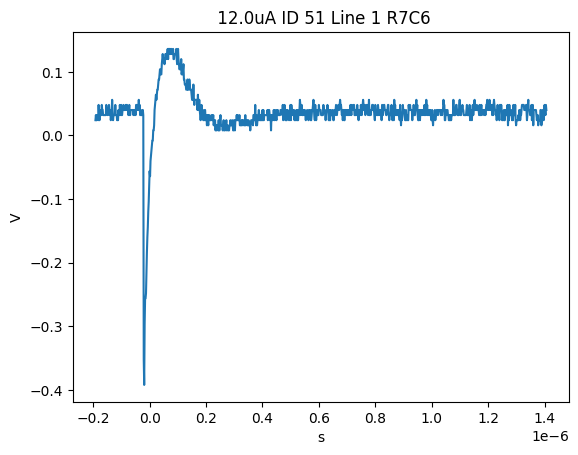

In [417]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')


Running dark coutns script with fiber port open 

In [419]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_parameter(dmm.volt)

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(6e-6, 15e-6, 1e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                            (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


Starting experimental run with id: 53. 
53
This acquisition will take 10s
14 3
This acquisition will take 10s
14 3
This acquisition will take 10s
14 4
This acquisition will take 10s
14 4
This acquisition will take 10s
14 4
This acquisition will take 10s
14 4
This acquisition will take 10s
14 5
This acquisition will take 10s
14 5
This acquisition will take 10s
14 5


In [420]:
ID = 53
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
voltage = data['dmm_volt']['dmm_volt']

plt.title(f'{device_name_1} Count Rate vs Voltage on Attenuator ID {ID}\nIbias={current[0]}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])


KeyError: 'dmm_volt'

In [421]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_parameter(dmm.volt)

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(6e-6, 15e-6, 1e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                            (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


Starting experimental run with id: 54. 
54
This acquisition will take 10s
15 28
This acquisition will take 10s
15 28
This acquisition will take 10s
15 28
This acquisition will take 10s
15 28
This acquisition will take 10s
15 29
This acquisition will take 10s
15 29
This acquisition will take 10s
15 29
This acquisition will take 10s
15 29
This acquisition will take 10s
15 30


Text(0, 0.5, 'Voltage (mV)')

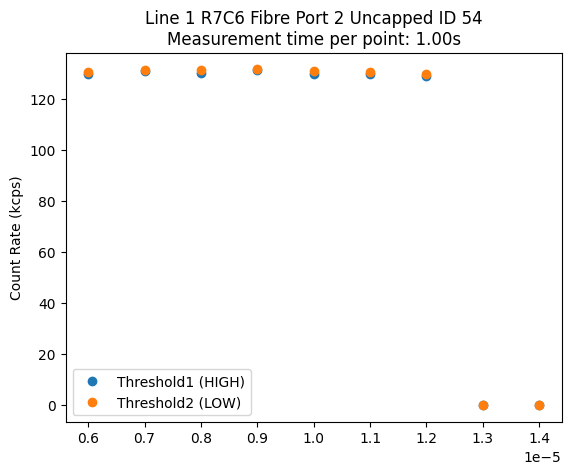

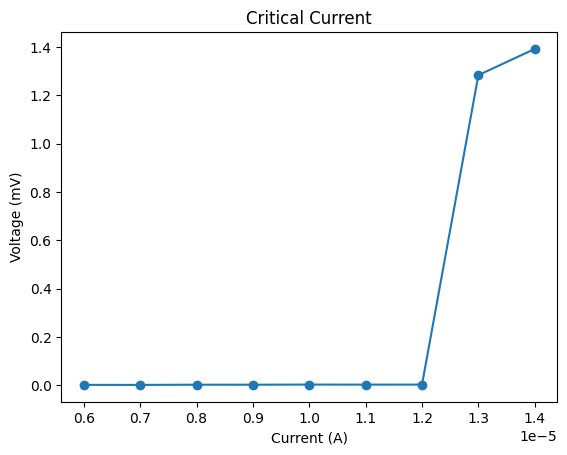

In [446]:
ID = 54
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']



plt.title(f'{device_name_1} Fibre Port 2 Uncapped ID {ID}\nMeasurement time per point: {meas_time[0]:.2f}s')
plt.plot(current, CR1*1e-3, 'o')
plt.plot(current, CR2*1e-3, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')

plt.figure()
plt.title('Critical Current')
plt.plot(current, voltage*1e3, 'o-')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (mV)')


Capturing trace to see that it is not saturated

Starting experimental run with id: 62. 
62
all processes finished!


Text(0, 0.5, 'V')

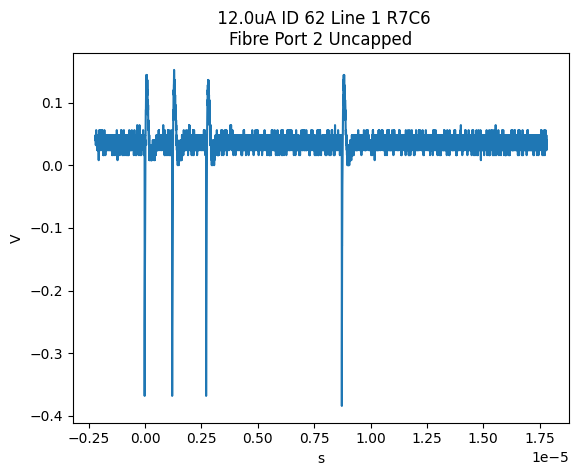

In [454]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 63. 
63
all processes finished!


Text(0, 0.5, 'V')

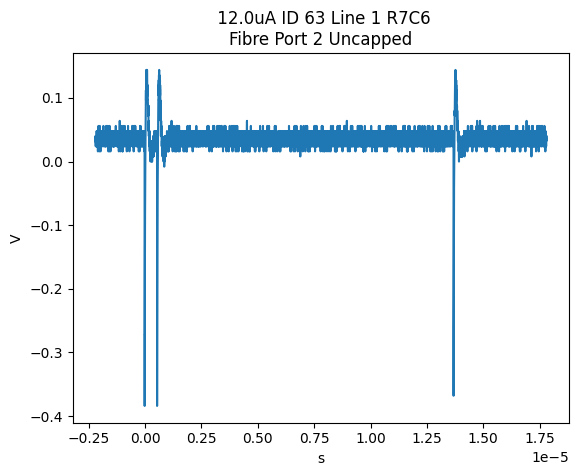

In [455]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 64. 
64
all processes finished!


Text(0, 0.5, 'V')

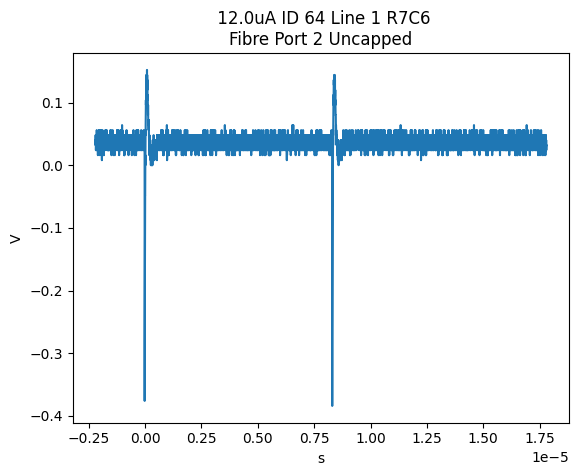

In [456]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 59. 
59
all processes finished!


Text(0, 0.5, 'V')

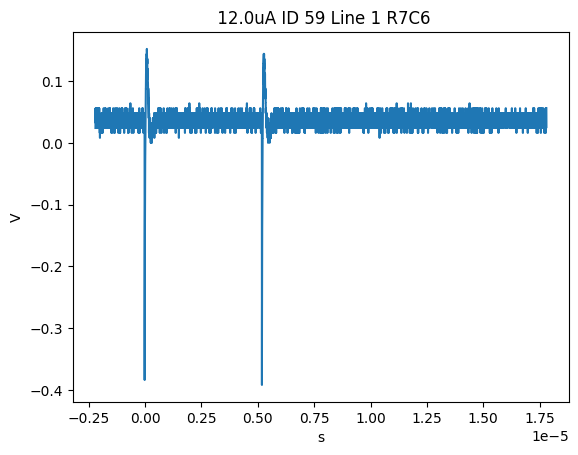

In [451]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 65. 
65
all processes finished!


Text(0, 0.5, 'V')

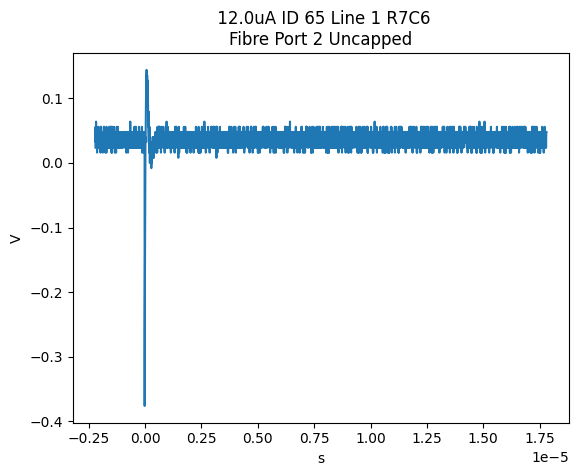

In [457]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 66. 
66
all processes finished!


Text(0, 0.5, 'V')

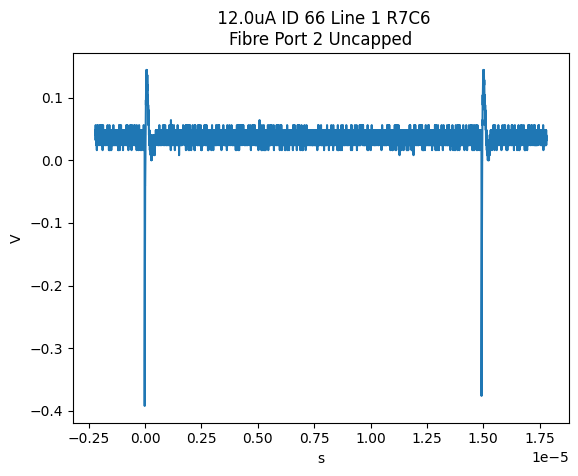

In [458]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

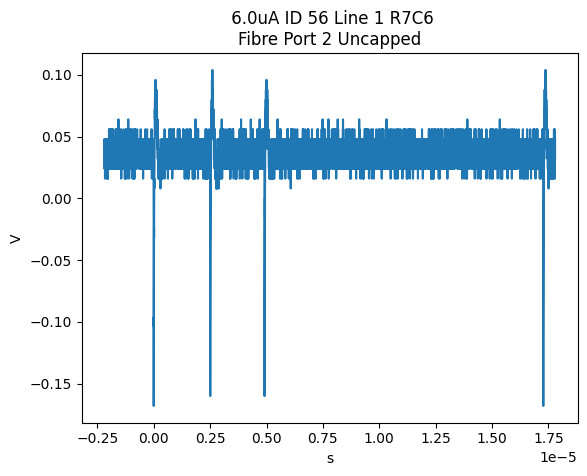

In [467]:
ID = 56
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

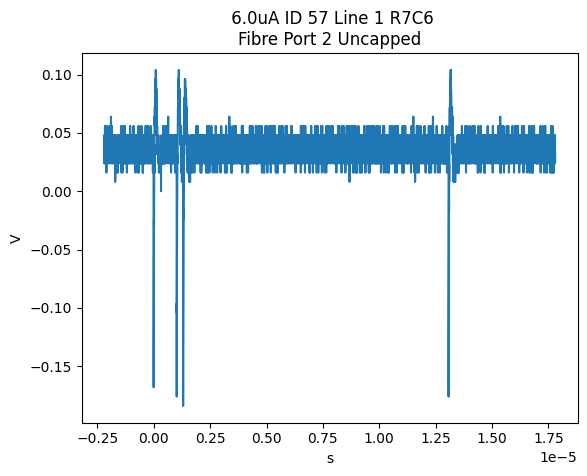

In [468]:
ID = 57
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

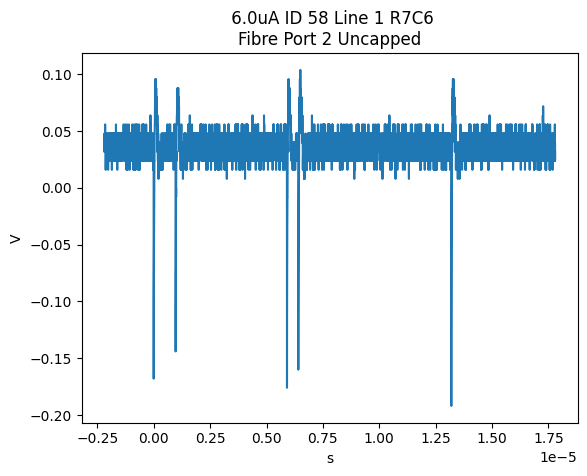

In [469]:
ID = 58
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')

Text(0, 0.5, 'V')

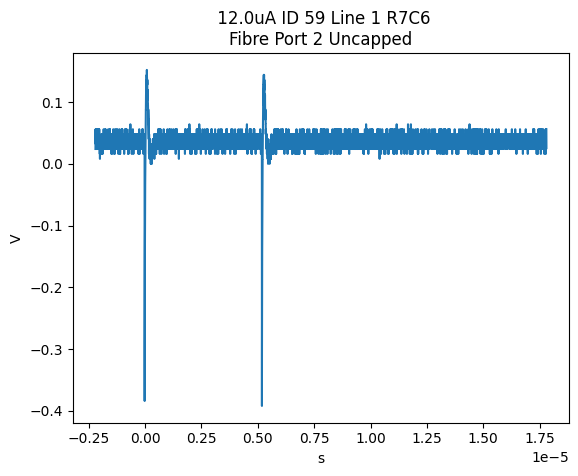

In [470]:
ID = 59
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

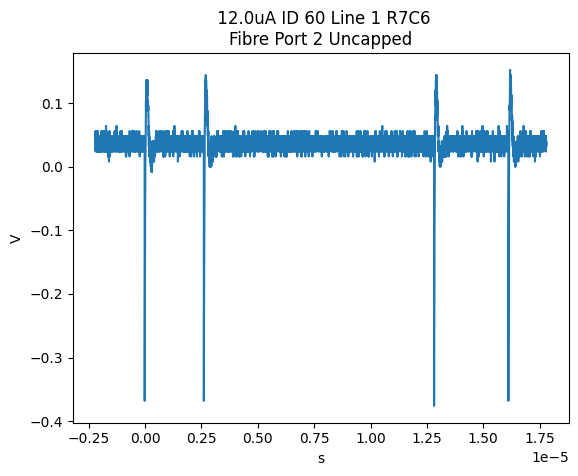

In [471]:
ID = 60
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

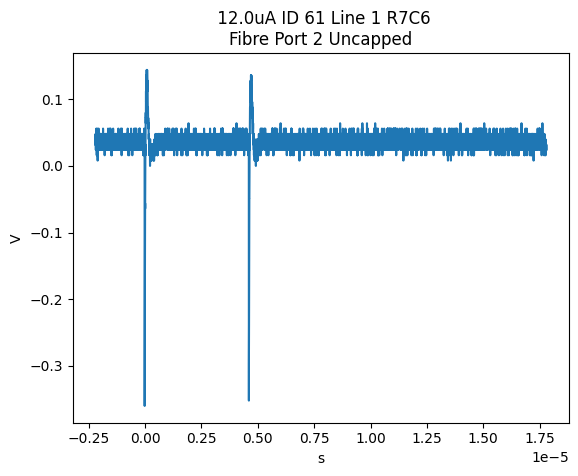

In [472]:
ID = 61
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

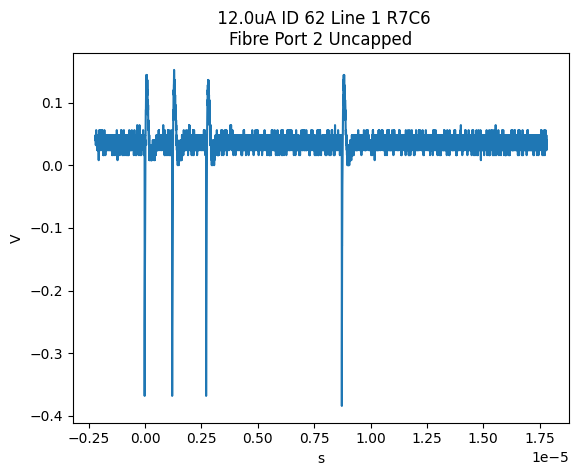

In [473]:
ID = 62
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 67. 
67
all processes finished!


Text(0, 0.5, 'V')

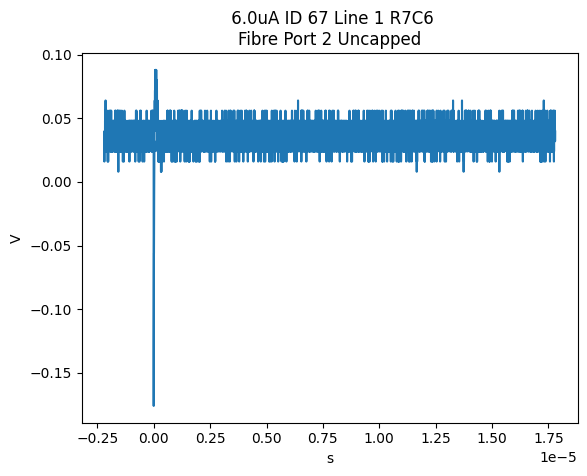

In [474]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)

yoko.current(6e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


REpeat light counts with wider range

In [494]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_parameter(dmm.volt)

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0, 15e-6, 1e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt

            
        else:
            threshold1 = -40e-3 # in volts
            threshold2 = -30e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                            (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


Starting experimental run with id: 71. 
71
This acquisition will take 10s
16 58
This acquisition will take 10s
16 58
This acquisition will take 10s
16 59
This acquisition will take 10s
16 59
This acquisition will take 10s
16 59
This acquisition will take 10s
16 59
This acquisition will take 10s
17 0
This acquisition will take 10s
17 0
This acquisition will take 10s
17 0
This acquisition will take 10s
17 0
This acquisition will take 10s
17 1
This acquisition will take 10s
17 1
This acquisition will take 10s
17 1
This acquisition will take 10s
17 1
This acquisition will take 10s
17 2
This acquisition will take 10s
17 2


Text(0, 0.5, 'Voltage (mV)')

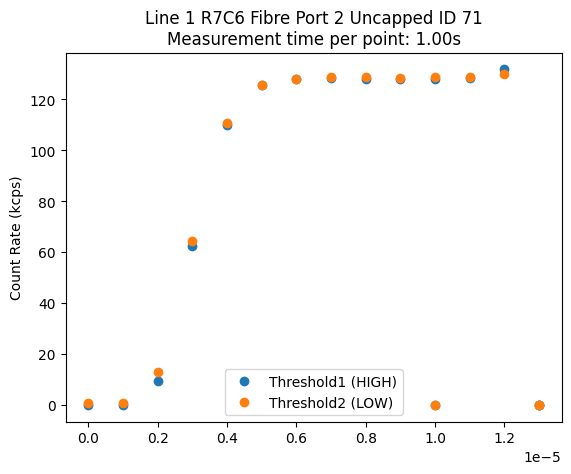

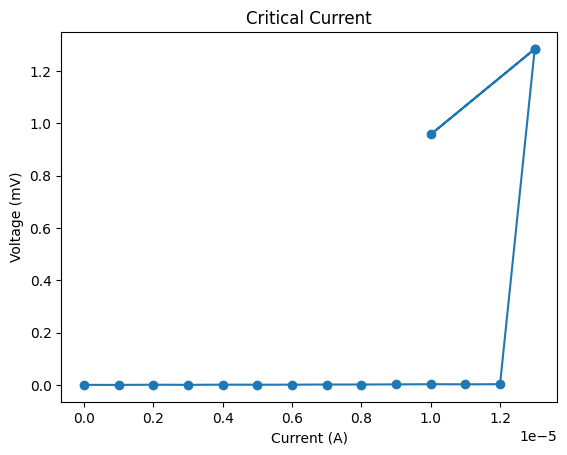

In [495]:
ID = 71
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']


plt.title(f'{device_name_1} Fibre Port 2 Uncapped ID {ID}\nMeasurement time per point: {meas_time[0]:.2f}s')
plt.plot(current, CR1*1e-3, 'o')
plt.plot(current, CR2*1e-3, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')

plt.figure()
plt.title('Critical Current')
plt.plot(current, voltage*1e3, 'o-')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (mV)')


Starting experimental run with id: 72. 
72
all processes finished!


Text(0, 0.5, 'V')

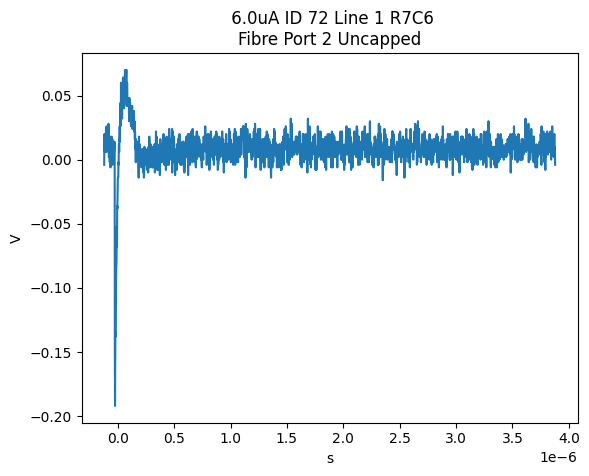

In [496]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)

yoko.current(6e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 78. 
78
all processes finished!


Text(0, 0.5, 'V')

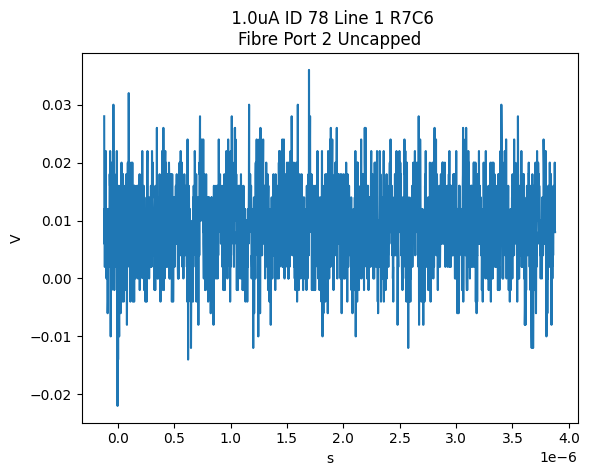

In [502]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)

yoko.current(1e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 73. 
73
all processes finished!


Text(0, 0.5, 'V')

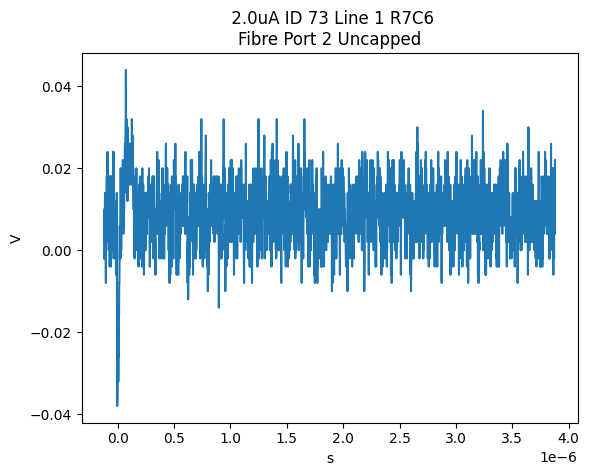

In [497]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)

yoko.current(2e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


Starting experimental run with id: 75. 
75
all processes finished!


Text(0, 0.5, 'V')

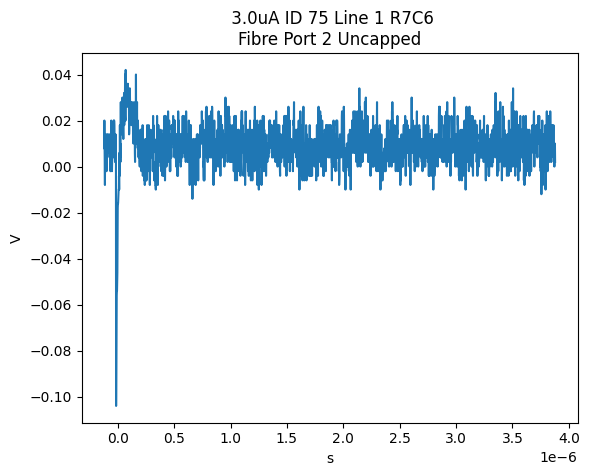

In [499]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)

yoko.current(3e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}\nFibre Port 2 Uncapped')
plt.xlabel('s')
plt.ylabel('V')


In [503]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_parameter(dmm.volt)

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0, 15e-6, 1e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt
        
        elif current > 4e-6: 
            threshold1 = -125e-3
            threshold2 = -30e-3
            
        elif current > 3e-6: 
            threshold1 = -100e-3
            threshold2 = -30e-3

        elif current > 2e-6: 
            threshold1 = -75e-3
            threshold2 = -30e-3
    
        else:
            threshold1 = -40e-3 # in volts
            threshold2 = -30e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                            (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))

# Ramp down 

for current in currents[::-1]:
    yoko.current(current)
    time.sleep(1)

print('Finished!')

Starting experimental run with id: 79. 
79
This acquisition will take 10s
17 11
This acquisition will take 10s
17 11
This acquisition will take 10s
17 11
This acquisition will take 10s
17 11
This acquisition will take 10s
17 12
This acquisition will take 10s
17 12
This acquisition will take 10s
17 12
This acquisition will take 10s
17 12
This acquisition will take 10s
17 13
This acquisition will take 10s
17 13
This acquisition will take 10s
17 13
This acquisition will take 10s
17 13
This acquisition will take 10s
17 14
This acquisition will take 10s
17 14
This acquisition will take 10s
17 14
This acquisition will take 10s
17 14
Finished!


Text(0, 0.5, 'Voltage (mV)')

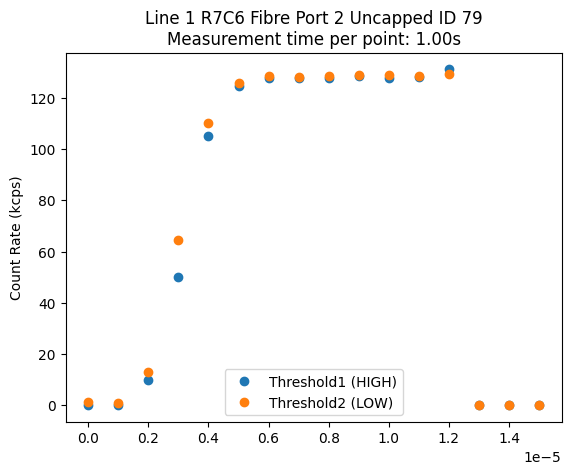

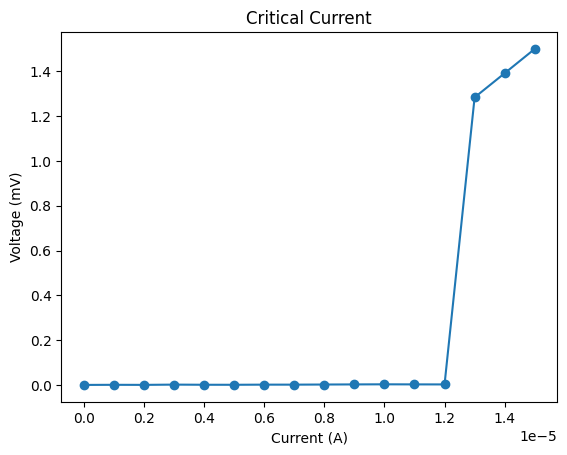

In [504]:
ID = 79
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']


plt.title(f'{device_name_1} Fibre Port 2 Uncapped ID {ID}\nMeasurement time per point: {meas_time[0]:.2f}s')
plt.plot(current, CR1*1e-3, 'o')
plt.plot(current, CR2*1e-3, 'o')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')

plt.figure()
plt.title('Critical Current')
plt.plot(current, voltage*1e3, 'o-')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (mV)')


Repeat light count sweep to see if the efficiency has changed now

In [505]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False
Finished!


In [506]:
pm120.power()

3.33054895e-09

Laser connected

In [519]:
p_att.write(f'VOLT 5')

In [516]:
p_att.write('[SOURce:]CHANnel:OUTPut[:STATe] ?')

In [510]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


In [520]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(6e-6, 14.25e-6, 0.25e-6)

v_attenuator = 5

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Set attenuator power 
    p_att.write(f'VOLT {v_attenuator}')
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'90% port power: {pm120.power()}')

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 4e-6: 
            threshold1 = -125e-3
            threshold2 = -30e-3
            
        elif current > 3e-6: 
            threshold1 = -100e-3
            threshold2 = -30e-3

        elif current > 2e-6: 
            threshold1 = -75e-3
            threshold2 = -30e-3
    
        else:
            threshold1 = -40e-3 # in volts
            threshold2 = -30e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                              (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2),
                            ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 82. 
82
Laser enable status: True
90% port power: 0.00424262555
This acquisition will take 10s
17 32
This acquisition will take 10s
17 33
This acquisition will take 10s
17 33
This acquisition will take 10s
17 33
This acquisition will take 10s
17 33
This acquisition will take 10s
17 34
This acquisition will take 10s
17 34
This acquisition will take 10s
17 34
This acquisition will take 10s
17 34
This acquisition will take 10s
17 35
This acquisition will take 10s
17 35
This acquisition will take 10s
17 35
This acquisition will take 10s
17 35
This acquisition will take 10s
17 36
This acquisition will take 10s
17 36
This acquisition will take 10s
17 36
This acquisition will take 10s
17 36
This acquisition will take 10s
17 37
This acquisition will take 10s
17 37
This acquisition will take 10s
17 37
This acquisition will take 10s
17 37
This acquisition will take 10s
17 38
This acquisition will take 10s
17 38
This acquisition will take 10s
17 38
This acquisit

Text(0.5, 0, 'Current (A)')

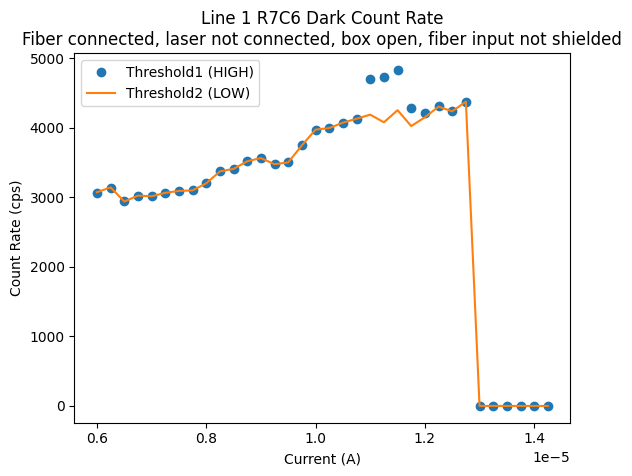

In [573]:
data = load_by_id(82).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
conditions = 'Fiber connected, laser not connected, box open, fiber input not shielded'

plt.title(f'{device_name_1} Dark Count Rate\n{conditions}')
plt.plot(current, CR1, 'o')
plt.plot(current, CR2)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel('Current (A)')


In [525]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0, 14.1e-6, 0.1e-6)

v_attenuator = 5

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Set attenuator power 
    p_att.write(f'VOLT {v_attenuator}')
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'90% port power: {pm120.power()}')

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 4e-6: 
            threshold1 = -125e-3
            threshold2 = -30e-3
            
        elif current > 3e-6: 
            threshold1 = -100e-3
            threshold2 = -30e-3

        elif current > 2e-6: 
            threshold1 = -75e-3
            threshold2 = -30e-3
    
        else:
            threshold1 = -40e-3 # in volts
            threshold2 = -30e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                              (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2),
                            ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 85. 
85
Laser enable status: True
90% port power: 0.00423270836
This acquisition will take 10s
17 47
This acquisition will take 10s
17 47
This acquisition will take 10s
17 47
This acquisition will take 10s
17 48
This acquisition will take 10s
17 48
This acquisition will take 10s
17 48
This acquisition will take 10s
17 48
This acquisition will take 10s
17 49
This acquisition will take 10s
17 49
This acquisition will take 10s
17 49
This acquisition will take 10s
17 49
This acquisition will take 10s
17 50
This acquisition will take 10s
17 50
This acquisition will take 10s
17 50
This acquisition will take 10s
17 50
This acquisition will take 10s
17 51
This acquisition will take 10s
17 51
This acquisition will take 10s
17 51
This acquisition will take 10s
17 51
This acquisition will take 10s
17 52
This acquisition will take 10s
17 52
This acquisition will take 10s
17 52
This acquisition will take 10s
17 52
This acquisition will take 10s
17 53
This acquisit

Box is open for this measurement

In [527]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False


Text(0.5, 0, 'Current (A)')

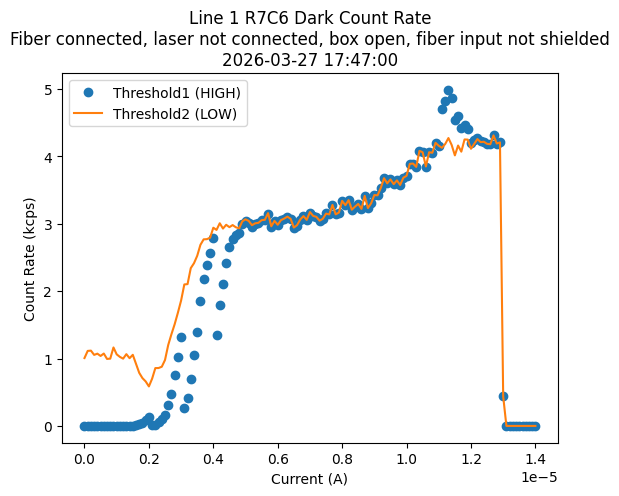

In [741]:
ID = 85
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
conditions = 'Fiber connected, laser not connected, box open, fiber input not shielded'
timestamp = load_by_id(ID).run_timestamp()

plt.title(f'{device_name_1} Dark Count Rate\n{conditions}\n{timestamp}')
plt.plot(current, CR1*1e-3, 'o')
plt.plot(current, CR2*1e-3)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')
plt.xlabel('Current (A)')

In [564]:
v_attenuator

array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5.])

Text(0.5, 0, 'Current(A)')

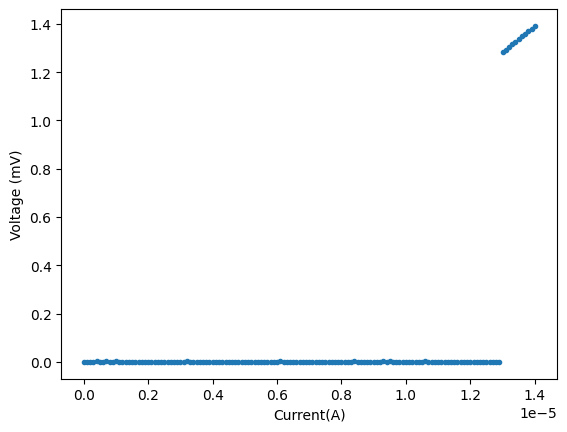

In [541]:
plt.plot(current, voltage*1e3, '.')
plt.ylabel('Voltage (mV)')
plt.xlabel('Current(A)')

In [554]:
datasaver.dataset

results #85@D:\SNSPD\SNSPD2\2026-03-10_SNSPD4.db
------------------------------------------------
yoko_current - numeric
dmm_volt - numeric
threshold1 - numeric
threshold2 - numeric
total_counts1 - numeric
total_counts2 - numeric
counts1 - numeric
counts2 - numeric
trace_time - numeric
meas_time - numeric
bin_length - numeric
CR1 - numeric
CR2 - numeric
n_captures - numeric
v_attenuator - numeric

In [551]:
type(datasaver.dataset)

qcodes.dataset.data_set.DataSet

In [547]:
datasaver.dataset.run_timestamp()

'2026-03-27 17:47:00'

In [549]:
datasaver.dataset.metadata # could add metadata 

{}

In [555]:
load_by_id(82).metadata

{}

In [556]:
load_by_id(82).run_timestamp()

'2026-03-27 17:32:39'

In [557]:
device_name_1

'Line 1 R7C6'

In [558]:
load_by_id(85).add_metadata("device", device_name_1)

In [561]:
load_by_id(85).metadata['device']

'Line 1 R7C6'

In [562]:
plot_by_id(85)

([], [])

# 30/3/26

Repeat light counts sweep with same current and threshold parameters as ID 12. 

In [567]:
device = device_name_1

In [568]:
device

'Line 1 R7C6'

In [577]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)
print(f'90% port power: {pm120.power()}')

Laser enable status: True
90% port power: 0.00441361312


In [578]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [588]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1  
currents = np.arange(6e-6, 14.25e-6, 0.25e-6)
v_attenuator = 5
device = device_name_1

# Set current to zero 
yoko.current(0)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Set attenuator power 
    p_att.write(f'VOLT {v_attenuator}')
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'90% port power: {pm120.power()}')

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                              (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2),
                            ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Ramping down')
# Ramp down current 
for current in np.arange(currents[-1], 0.8e-6, -0.2e-6): 
    # Set current 
    yoko.current(current)
    time.sleep(1)

yoko.current(0)

print('Finished!')

Starting experimental run with id: 88. 
88
Laser enable status: True
90% port power: 0.00442332122
This acquisition will take 10s
11 30
This acquisition will take 10s
11 31
This acquisition will take 10s
11 31
This acquisition will take 10s
11 31
This acquisition will take 10s
11 31
This acquisition will take 10s
11 32
This acquisition will take 10s
11 32
This acquisition will take 10s
11 32
This acquisition will take 10s
11 32
This acquisition will take 10s
11 33
This acquisition will take 10s
11 33
This acquisition will take 10s
11 33
This acquisition will take 10s
11 33
This acquisition will take 10s
11 34
This acquisition will take 10s
11 34
This acquisition will take 10s
11 34
This acquisition will take 10s
11 34
This acquisition will take 10s
11 35
This acquisition will take 10s
11 35
This acquisition will take 10s
11 35
This acquisition will take 10s
11 35
This acquisition will take 10s
11 36
This acquisition will take 10s
11 36
This acquisition will take 10s
11 36
This acquisit

Trigger issue around 11uA. Run that part to check 

In [590]:
print('ramping up')
for current in np.arange(0, currents[0], 1e-6):
    yoko.current(current)
    time.sleep(1)


ramping up


In [591]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1  
currents = np.arange(10e-6, 12.25e-6, 0.25e-6)
v_attenuator = 5
device = device_name_1

# # Set current to zero 
# yoko.current(0)

# # Ramp up to start value
# print('ramping up')
# for current in np.arange(0, currents[0], 1e-6):
#     yoko.current(current)
#     time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Set attenuator power 
    p_att.write(f'VOLT {v_attenuator}')
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'90% port power: {pm120.power()}')

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                              (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2),
                            ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Ramping down')
# Ramp down current 
for current in np.arange(currents[-1], 0.8e-6, -0.2e-6): 
    # Set current 
    yoko.current(current)
    time.sleep(1)

yoko.current(0)

print('Finished!')

Starting experimental run with id: 89. 
89
Laser enable status: True
90% port power: 0.00443835324
This acquisition will take 10s
11 50
This acquisition will take 10s
11 51
This acquisition will take 10s
11 51
This acquisition will take 10s
11 51
This acquisition will take 10s
11 51
This acquisition will take 10s
11 52
This acquisition will take 10s
11 52
This acquisition will take 10s
11 52


An exception occurred in measurement with guid: 21f8e85a-0000-0000-0000-019d3c387cd7;
Traceback:
Traceback (most recent call last):
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_8972\2150356508.py", line 100, in <module>
    time.sleep(5)
KeyboardInterrupt



KeyboardInterrupt: 

In [592]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [594]:
current = 7e-6
yoko.current(current)
# set thresholds depending on currents 
if current > 13e-6:
    threshold1 = -330e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 11e-6:
    threshold1 = -276e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 9e-6:
    threshold1 = -237e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 7e-6:
    threshold1 = -177e-3 # in volts
    threshold2 = -50e-3 # in volt


else:
    threshold1 = -126e-3 # in volts
    threshold2 = -50e-3 # in volt

# Set thresholds  
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

In [599]:
# Set horizontal scale to 10ms per division 
MS.write('VER:MODe:SCAle ?') # sets scale in seconds per division, max appears to be 10e-3

# Set horizontal scale position to 0 
MS.write('VER:POSition 0') 

In [603]:
# Set horizontal scale to 10ms per division 
print(MS.write('AUTOSet:HORizontal:ENAble?')) # sets scale in seconds per division, max appears to be 10e-3


None


In [605]:
# Set horizontal scale to 10ms per division 
MS.write('HORizontal:MODe:SCAle 50-6') # sets scale in seconds per division, max appears to be 10e-3

# Set horizontal scale position to 0 
MS.write('HORizontal:POSition 0') 

In [612]:
print(MS.write('HORizontal:MODe:SCAle?'))

None


Horizontal rescaling is also not working at the moment. 

In [610]:
MS.write('SEL:CH1 ON')

In [611]:
MS.ask("SEARCH:SEARCH1:TOTal?")

'57'

In [614]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1  
currents = np.arange(10e-6, 12.25e-6, 0.25e-6)
v_attenuator = 5
device = device_name_1

# # Set current to zero 
# yoko.current(0)

# # Ramp up to start value
# print('ramping up')
# for current in np.arange(0, currents[0], 1e-6):
#     yoko.current(current)
#     time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Set attenuator power 
    p_att.write(f'VOLT {v_attenuator}')
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'90% port power: {pm120.power()}')

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                              (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2),
                            ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Ramping down')
# Ramp down current 
for current in np.arange(currents[-1], 0.8e-6, -0.2e-6): 
    # Set current 
    yoko.current(current)
    time.sleep(1)

yoko.current(0)

print('Finished!')

Starting experimental run with id: 90. 
90
Laser enable status: True
90% port power: 0.00444242405
This acquisition will take 10s
14 40
This acquisition will take 10s
14 40
This acquisition will take 10s
14 40
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 42
This acquisition will take 10s
14 42
Laser enable status: False
Ramping down
Finished!


In [615]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1  
currents = np.arange(6e-6, 14.25e-6, 0.25e-6)
v_attenuator = 5
device = device_name_1

# Set current to zero 
yoko.current(0)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Set attenuator power 
    p_att.write(f'VOLT {v_attenuator}')
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    
    ############################ TURN LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'90% port power: {pm120.power()}')

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                              (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2),
                            ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Ramping down')
# Ramp down current 
for current in np.arange(currents[-1], 0.8e-6, -0.2e-6): 
    # Set current 
    yoko.current(current)
    time.sleep(1)

yoko.current(0)

print('Finished!')

Starting experimental run with id: 91. 
91
Laser enable status: True
90% port power: 0.00445275847
This acquisition will take 10s
14 45
This acquisition will take 10s
14 45
This acquisition will take 10s
14 45
This acquisition will take 10s
14 46
This acquisition will take 10s
14 46
This acquisition will take 10s
14 46
This acquisition will take 10s
14 46
This acquisition will take 10s
14 47
This acquisition will take 10s
14 47
This acquisition will take 10s
14 47
This acquisition will take 10s
14 47
This acquisition will take 10s
14 48
This acquisition will take 10s
14 48
This acquisition will take 10s
14 48
This acquisition will take 10s
14 48
This acquisition will take 10s
14 49
This acquisition will take 10s
14 49
This acquisition will take 10s
14 49
This acquisition will take 10s
14 49
This acquisition will take 10s
14 50
This acquisition will take 10s
14 50
This acquisition will take 10s
14 50
This acquisition will take 10s
14 50
This acquisition will take 10s
14 51
This acquisit

In [ ]:
if yoko.current() > 

Sweep with attenuator

In [618]:
meas = Measurement()
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1 # s <-  
# set current near transition based on ID 12 
current = 12e-6
device = device_name_1
voltages = np.arange(3.4, 7.05, 0.05) # <- sweep parameter is voltage applied to attnuator

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    # Set attenuator to 5V
    p_att.write(f'VOLT 5')
    time.sleep(5)
    
    # LASER ON # 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    
    print(f'Power 90% port: {pm120.power()}')
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    # Set current
    yoko.current(current)
    time.sleep(1)

    for v_attenuator in voltages[::-1]: # <- sweep voltage applied to attenuator
        
        p_att.write(f'VOLT {v_attenuator}')
        print(f'Starting V={v_attenuator}')
        time.sleep(1)
          

        # Thresholds from ID 12 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt
            

        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2), 
                             ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 93. 
93
Laser enable status: True
Power 90% port: 0.00445181923
Starting V=6.999999999999988
This acquisition will take 10s
14 59
Starting V=6.949999999999987
This acquisition will take 10s
14 59
Starting V=6.899999999999988
This acquisition will take 10s
15 0
Starting V=6.849999999999987
This acquisition will take 10s
15 0
Starting V=6.799999999999988
This acquisition will take 10s
15 0
Starting V=6.749999999999988
This acquisition will take 10s
15 0
Starting V=6.699999999999989
This acquisition will take 10s
15 1
Starting V=6.649999999999988
This acquisition will take 10s
15 1
Starting V=6.599999999999989
This acquisition will take 10s
15 1
Starting V=6.549999999999988
This acquisition will take 10s
15 1
Starting V=6.499999999999989
This acquisition will take 10s
15 2
Starting V=6.449999999999989
This acquisition will take 10s
15 2
Starting V=6.39999999999999
This acquisition will take 10s
15 2
Starting V=6.349999999999989
This acquisition will take

In [ ]:
for v_attenuator in voltages: # <- sweep voltage applied to attenuator
        
    p_att.write(f'VOLT {v_attenuator}')
    print(f'Starting V={v_attenuator}')
    time.sleep(1)

In [619]:
p_att.write(f'VOLT 5')

In [617]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


Extract traces at attenuation before transition

In [620]:
p_att.write(f'VOLT 4')

Starting experimental run with id: 96. 
96
Laser enable status: False
Finished!
all processes finished!


Text(0, 0.5, 'V')

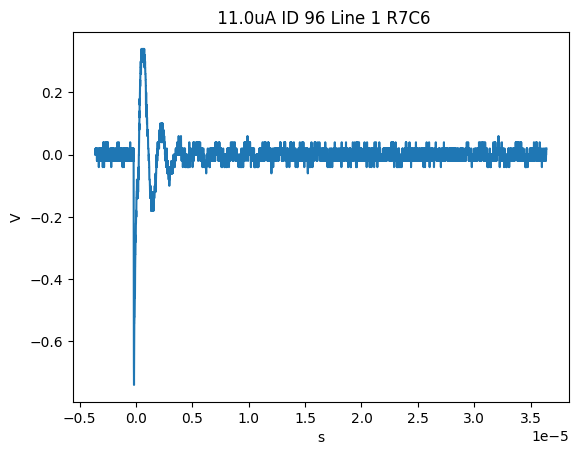

In [627]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1

# Set attenuator to 4V
# p_att.write(f'VOLT 4')

# print('ramping')
# set current to 12uA 
# for current in np.arange(0, 13e-6, 1e-6):
#     yoko.current(current)
#     time.sleep(1)

# ############################ LASER ON ############################ 
# laser.enable(True)
# print(f'Laser enable status: {laser.enable()}')
# time.sleep(10)
# print(f'Power 90% port: {pm120.power()}')


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

print('all processes finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')


In [623]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


In [624]:
laser.enable()

False

In [629]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")


device = device_name_1
currents = np.arange(8e-6, 18e-6, 0.5e-6)


ramp_up = np.arange(0, currents[0], 0.5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 98. 
98
Start current 8e-06
Start current 8.5e-06
Start current 9e-06
Start current 9.5e-06
Start current 1e-05
Start current 1.0500000000000001e-05
Start current 1.1000000000000001e-05
Start current 1.1500000000000002e-05
Start current 1.2000000000000002e-05
Start current 1.2500000000000002e-05
Start current 1.3000000000000003e-05
Start current 1.3500000000000003e-05
Start current 1.4000000000000003e-05
Start current 1.4500000000000003e-05
Start current 1.5000000000000004e-05
Start current 1.5500000000000004e-05
Start current 1.6000000000000003e-05
Start current 1.6500000000000005e-05
Start current 1.7000000000000007e-05
Start current 1.7500000000000005e-05
Start current 1.8000000000000004e-05
Ramping down
Current is 8e-06
Finished!


In [630]:
p_att.write(f'VOLT 5')

In [631]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set attenuator to 5V
p_att.write(f'VOLT 5')

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:5.50964829e-09
Power on PM120 after 90% beamsplitter port is:0.00445244554
Attenuation is:48.930010394593594
Laser enable status: False


In [ ]:
device = device_name_1
voltages = np.arange(3.4, 7.05, 0.05)

In [637]:

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")
meas.register_custom_parameter("v_attenuator", label="V")
meas.register_custom_parameter("avg_attenuation", label="dB")


voltages = np.arange(4.8, 5.2, 0.2)


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    ############################ LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'Power 90% port: {pm120.power()}')

    for v_attenuator in voltages: 
        p_att.write(f'VOLT {v_attenuator}')
        print(v_attenuator)
        time.sleep(1)

        bs90 = 0.9118079062146573
        bs10 = 0.08819209378534265

        start = time.perf_counter()

        power_90 = []
        power_out = []
        times = []
        attenuation = []


        for i in range (20):
            t=i*0.5
            p1= pm120.power() # laser 
            p2 = powermeter.power() # attenuator output 
            p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
            time.sleep(0.5) # acquire every half second

            power_90.append(p1)
            power_out.append(p2)
            times.append(t)
            attenuation.append(p)

        datasaver.add_result(("times",times),
                         ("p1", power_90),
                        ("p2", power_out),
                        ("attenuation", attenuation), 
                        ("v_attenuator", v_attenuator),
                        ('avg_attenuation', np.average(attenuation)))

    end = time.perf_counter()
    print(end-start)


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('finished!')

Starting experimental run with id: 105. 
105
Laser enable status: True
Power 90% port: 0.0044496269
4.8
5.0
5.2
10.17307250003796
Laser enable status: False
finished!


In [638]:
meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")
meas.register_custom_parameter("v_attenuator", label="V")
meas.register_custom_parameter("avg_attenuation", label="dB")


voltages = np.arange(3.4, 7.05, 0.05)


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    ############################ LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'Power 90% port: {pm120.power()}')

    for v_attenuator in voltages: 
        p_att.write(f'VOLT {v_attenuator}')
        print(v_attenuator)
        time.sleep(1)

        bs90 = 0.9118079062146573
        bs10 = 0.08819209378534265

        start = time.perf_counter()

        power_90 = []
        power_out = []
        times = []
        attenuation = []


        for i in range (60):
            t=i*0.5
            p1= pm120.power() # laser 
            p2 = powermeter.power() # attenuator output 
            p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
            time.sleep(0.5) # acquire every half second

            power_90.append(p1)
            power_out.append(p2)
            times.append(t)
            attenuation.append(p)

        datasaver.add_result(("times",times),
                         ("p1", power_90),
                        ("p2", power_out),
                        ("attenuation", attenuation), 
                        ("v_attenuator", v_attenuator),
                        ('avg_attenuation', np.average(attenuation)))

    end = time.perf_counter()
    print(end-start)


############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('finished!')

Starting experimental run with id: 106. 
106
Laser enable status: True
Power 90% port: 0.00444242405
3.4
3.4499999999999997
3.4999999999999996
3.5499999999999994
3.599999999999999
3.649999999999999
3.699999999999999
3.7499999999999987
3.7999999999999985
3.8499999999999983
3.899999999999998
3.949999999999998
3.999999999999998
4.049999999999997
4.099999999999998
4.149999999999997
4.1999999999999975
4.2499999999999964
4.299999999999997
4.349999999999996
4.399999999999997
4.449999999999996
4.4999999999999964
4.549999999999995
4.599999999999996
4.649999999999995
4.699999999999996
4.749999999999995
4.799999999999995
4.849999999999994
4.899999999999995
4.949999999999994
4.999999999999995
5.049999999999994
5.099999999999994
5.149999999999993
5.199999999999994
5.249999999999993
5.299999999999994
5.3499999999999925
5.399999999999993
5.449999999999992
5.499999999999993
5.549999999999992
5.5999999999999925
5.6499999999999915
5.699999999999992
5.749999999999991
5.799999999999992
5.849999999999991
5

In [ ]:
import scipy.constants as spc 
wavelength = 1550e-9 
f = spc.c/wavelength 
Ephoton = spc.h*f

N_photons = []

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser =  0.00484314281/bs90
Pin = Plaser*bs10 # power reaching attenuators 

for i in avg_att: # go through values measured for average attenuation

    Patt_VOA1550PA = -i 
    Patt_VOA50PM_APC = -48.5 # measurement 3 ID 16
    # Patt_fiber_2 = -1.044 

    # Pin_dBm = 10*np.log10(Pin/1e-3) # power reaching attenuators in dBm
    # Pdevice_dBm =  Pin_dBm - Patt_VOA1550PA -  Patt_VOA50PM_APC  # power reaching device in dBm
    # Pdevice = 10**(Pdevice_dBm/10)

    total_attenuation_fiber2 = Patt_VOA1550PA + Patt_VOA50PM_APC
    Pdevice = Pin*(10**(total_attenuation_fiber2/10))

    N_photons.append(Pdevice/Ephoton)


plt.figure()
plt.plot(v_applied, N_photons, 'o')
plt.xlabel('Voltage Applied to Attenuator')
plt.ylabel('Number of photons/sec')

# 31/3/26

Comparing to ID 96 after time away. Noise trace and count trace. 

Starting experimental run with id: 107. 
107
Laser enable status: False
Finished!
all processes finished!


Text(0, 0.5, 'V')

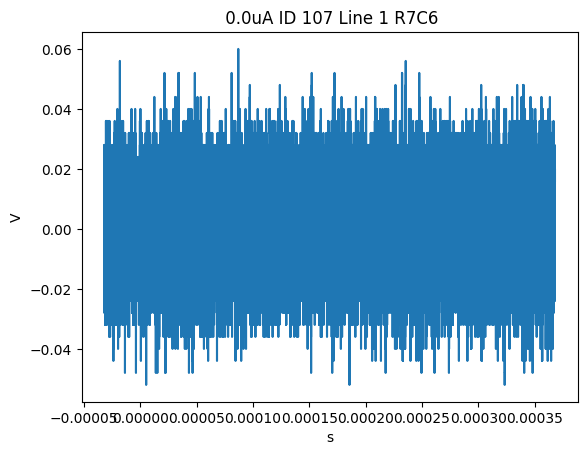

In [640]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1

# Set attenuator to 4V
# p_att.write(f'VOLT 4')

# print('ramping')
# set current to 12uA 
# for current in np.arange(0, 13e-6, 1e-6):
#     yoko.current(current)
#     time.sleep(1)

# ############################ LASER ON ############################ 
# laser.enable(True)
# print(f'Laser enable status: {laser.enable()}')
# time.sleep(10)
# print(f'Power 90% port: {pm120.power()}')


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')


In [645]:
yoko.current(0)

In [646]:
yoko.ramp_current(11e-6, 0.5e-6, 1)

Starting experimental run with id: 108. 
108
Finished!


Text(0, 0.5, 'V')

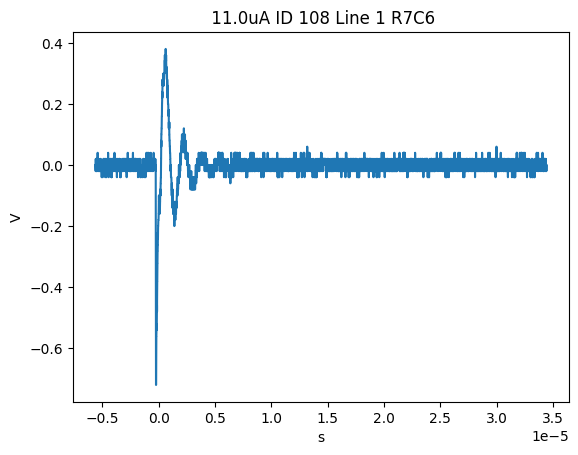

In [647]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1

# Set attenuator to 4V
# p_att.write(f'VOLT 4')

# print('ramping')
# set current to 12uA 
# for current in np.arange(0, 13e-6, 1e-6):
#     yoko.current(current)
#     time.sleep(1)

# ############################ LASER ON ############################ 
# laser.enable(True)
# print(f'Laser enable status: {laser.enable()}')
# time.sleep(10)
# print(f'Power 90% port: {pm120.power()}')


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')

Disconnecting and reconnecting. Turned off both amplifiers, disconnected scope, then reconnected and turned on both amplifiers 

Starting experimental run with id: 109. 
109
Finished!


Text(0, 0.5, 'V')

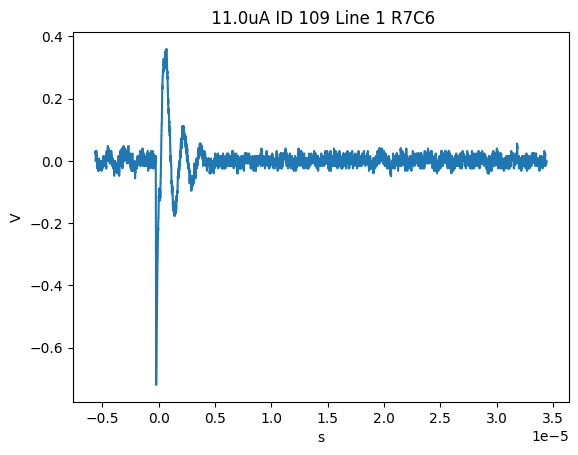

In [648]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1

# Set attenuator to 4V
# p_att.write(f'VOLT 4')

# print('ramping')
# set current to 12uA 
# for current in np.arange(0, 13e-6, 1e-6):
#     yoko.current(current)
#     time.sleep(1)

# ############################ LASER ON ############################ 
# laser.enable(True)
# print(f'Laser enable status: {laser.enable()}')
# time.sleep(10)
# print(f'Power 90% port: {pm120.power()}')


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')

Thresholds for oscilloscope meausremeents may have to change. 

In [649]:
# Set thresholds  
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

Run dark counts just to see how badly off the settings are 

In [651]:
laser.enable()

False

In [652]:
p_att.write(f'VOLT 5')

In [656]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_parameter(dmm.volt)


device = device_name_1
n_captures = 10
bin_length = 1 # s <-  
currents = np.arange(0e-6, 14.25e-6, 0.25e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    datasaver.dataset.add_metadata("device", device)
    

    for current in currents: 
        # Set current 
        yoko.current(current)

        # set thresholds depending on currents 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                            (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2))


print('Finished!')

Starting experimental run with id: 111. 
111
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 41
This acquisition will take 10s
14 42
This acquisition will take 10s
14 42
This acquisition will take 10s
14 42
This acquisition will take 10s
14 42
This acquisition will take 10s
14 43
This acquisition will take 10s
14 43
This acquisition will take 10s
14 43
This acquisition will take 10s
14 43
This acquisition will take 10s
14 44
This acquisition will take 10s
14 44
This acquisition will take 10s
14 44
This acquisition will take 10s
14 44
This acquisition will take 10s
14 45
This acquisition will take 10s
14 45
This acquisition will take 10s
14 45
This acquisition will take 10s
14 45
This acquisition will take 10s
14 46
This acquisition will take 10s
14 46
This acquisition will take 10s
14 46
This acquisition will take 10s
14 46
This acquisition will take 10s
14 47
This acquisition will take 10s
14 47


An exception occurred in measurement with guid: fb4a652e-0000-0000-0000-019d41fb4d69;
Traceback:
Traceback (most recent call last):
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_8972\441745276.py", line 88, in <module>
    time.sleep(bin_length)
KeyboardInterrupt



KeyboardInterrupt: 

Quite badly off! 

In [657]:
import time

print('VOA50PM-APC')

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set attenuator to 5V
p_att.write(f'VOLT 5')

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

VOA50PM-APC
Laser enable status: True
 Power on PM100USB after attenuator is:6.32978248e-09
Power on PM120 after 90% beamsplitter port is:0.00447081774
Attenuation is:48.34524479353316
Laser enable status: False


In [658]:
import time

print('VOA50PM-APC')

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set attenuator to 5V
p_att.write(f'VOLT 5')

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

VOA50PM-APC
Laser enable status: True
 Power on PM100USB after attenuator is:9.18399579e-09
Power on PM120 after 90% beamsplitter port is:0.00446382398
Attenuation is:46.72201684732058
Laser enable status: False


In [659]:
import time

print('VOA50PM-APC')

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set attenuator to 5V
p_att.write(f'VOLT 5')

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

VOA50PM-APC
Laser enable status: True
 Power on PM100USB after attenuator is:1.56278795e-10
Power on PM120 after 90% beamsplitter port is:0.00447739428
Attenuation is:64.42651585977896
Laser enable status: False


In [660]:
import time

print('VOA50PM-APC')

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)


bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

VOA50PM-APC
Laser enable status: True
 Power on PM100USB after attenuator is:2.00071799e-11
Power on PM120 after 90% beamsplitter port is:0.00446340628
Attenuation is:73.34006842688856
Laser enable status: False


In [661]:
import time

print('VOA50PM-APC')

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)


bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

VOA50PM-APC
Laser enable status: True
 Power on PM100USB after attenuator is:5.12618871e-11
Power on PM120 after 90% beamsplitter port is:0.00446632924
Attenuation is:69.25682444360137
Laser enable status: False


In [662]:
import time

print('VOA50PM-APC')

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)


bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

VOA50PM-APC
Laser enable status: True
 Power on PM100USB after attenuator is:4.87617551e-11
Power on PM120 after 90% beamsplitter port is:0.00447415793
Attenuation is:69.48158280699226
Laser enable status: False


Starting experimental run with id: 112. 
112
Finished!


Text(0, 0.5, 'V')

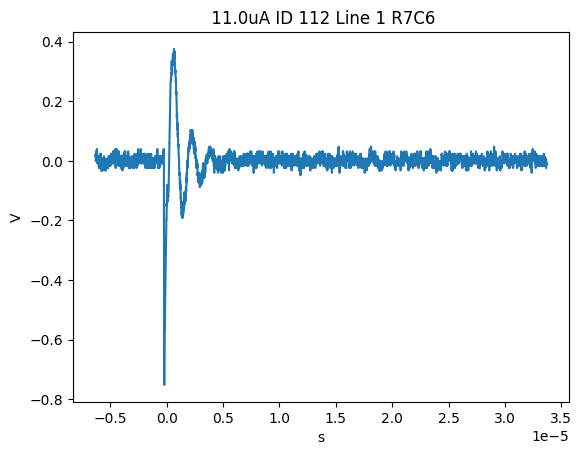

In [663]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1

# Set attenuator to 4V
# p_att.write(f'VOLT 4')

# print('ramping')
# set current to 12uA 
# for current in np.arange(0, 13e-6, 1e-6):
#     yoko.current(current)
#     time.sleep(1)

# ############################ LASER ON ############################ 
# laser.enable(True)
# print(f'Laser enable status: {laser.enable()}')
# time.sleep(10)
# print(f'Power 90% port: {pm120.power()}')


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')

Starting experimental run with id: 113. 
113
Finished!


Text(0, 0.5, 'V')

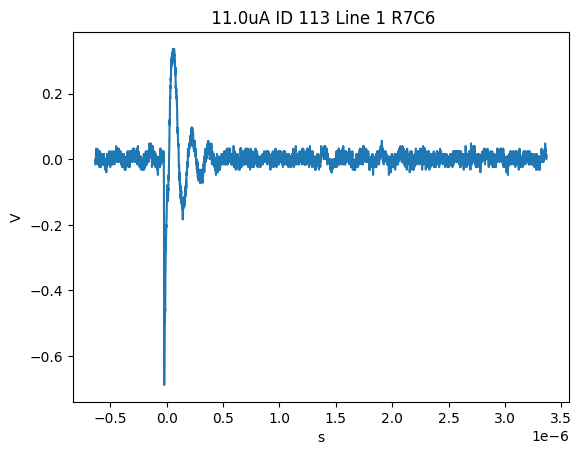

In [664]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1

# Set attenuator to 4V
# p_att.write(f'VOLT 4')

# print('ramping')
# set current to 12uA 
# for current in np.arange(0, 13e-6, 1e-6):
#     yoko.current(current)
#     time.sleep(1)

# ############################ LASER ON ############################ 
# laser.enable(True)
# print(f'Laser enable status: {laser.enable()}')
# time.sleep(10)
# print(f'Power 90% port: {pm120.power()}')


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')

In [666]:
laser.enable(False)

Starting experimental run with id: 114. 
114
Finished!


Text(0, 0.5, 'V')

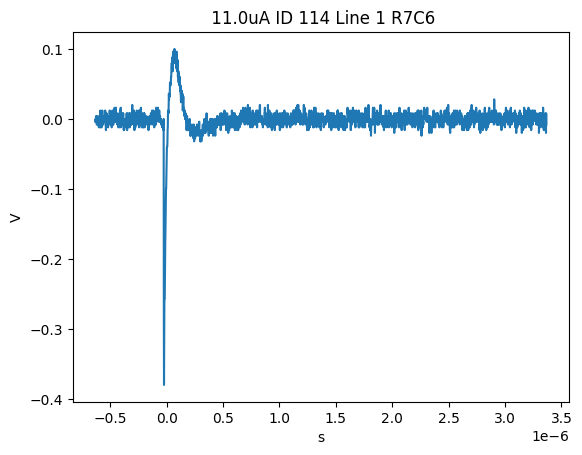

In [667]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')

Calibration of 

VOA50PM-APC
Laser enable status: True
Power 90% port: 0.00445171492
Starting experimental run with id: 115. 
115
307.13164350006264


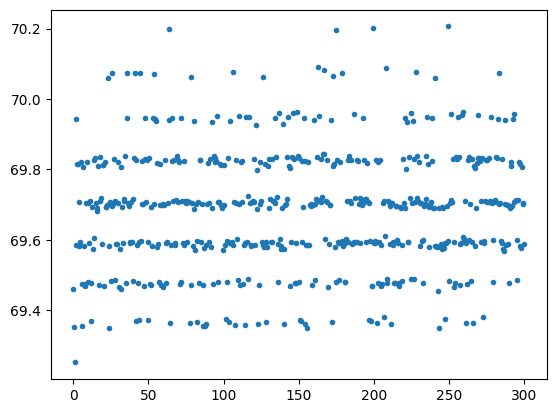

Laser enable status: False


In [668]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

print('VOA50PM-APC')

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265


############################ LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)
print(f'Power 90% port: {pm120.power()}')

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



VOA50PM-APC
Laser enable status: True
Power 90% port: 0.00445161061
Starting experimental run with id: 116. 
116
306.92770550004207


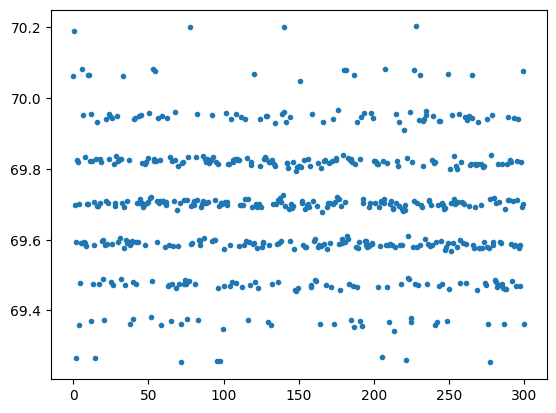

Laser enable status: False


In [669]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

print('VOA50PM-APC')

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265


############################ LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)
print(f'Power 90% port: {pm120.power()}')

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



# 1/4/26

Light counts sweep again - use exactly same sweep as ID 93. Fixed attenuator is now set to measured value

Optical arrangement is laser -> splitter -> fixed attenuator/screw att. -> voltage controlled attenuator -> fridge fiber -> device

Thresholds seem to need changing again 

In [671]:
current = yoko.current()
# Thresholds from ID 12 
if current > 13e-6:
    threshold1 = -330e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 11e-6:
    threshold1 = -276e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 9e-6:
    threshold1 = -237e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 7e-6:
    threshold1 = -177e-3 # in volts
    threshold2 = -50e-3 # in volt


else:
    threshold1 = -126e-3 # in volts
    threshold2 = -50e-3 # in volt


# Set thresholds  
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')


Starting experimental run with id: 117. 
117
Finished!


ValueError: x and y must have same first dimension, but have shapes (1250000,) and (1000000,)

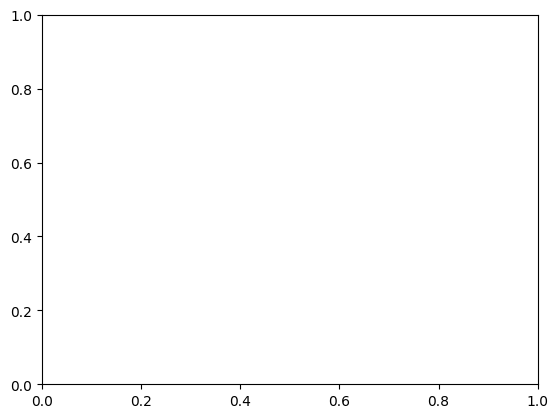

In [672]:
#####
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
device = device_name_1


with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)

    waveform = MS.waveform_data()
#     print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))
print('Finished!')


data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(trace)
plt.title(f' {current*1e6}uA ID {datasaver.run_id} {device_name_1}')
plt.xlabel('s')
plt.ylabel('V')

In [676]:
h_samplerate

31250000.0

In [677]:
h_samples

1250000

There are traces that appear very small, zooming on one to see if it actually looks like a count or noise

Text(0, 0.5, 'V')

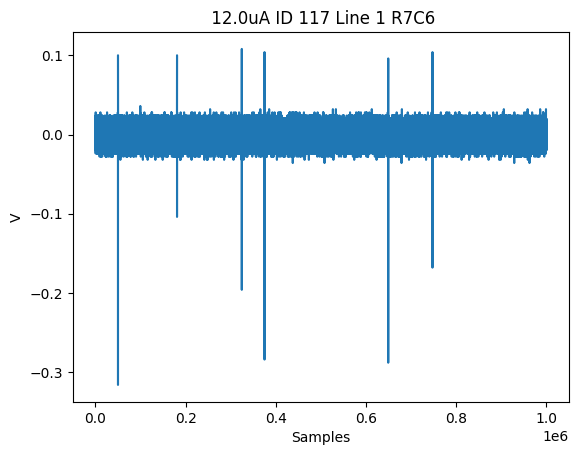

In [685]:
data = load_by_id(117).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(trace)
plt.title(f' {current*1e6}uA ID {117} {device_name_1}')
plt.xlabel('Samples')
plt.ylabel('V')

(-0.15, 0.15)

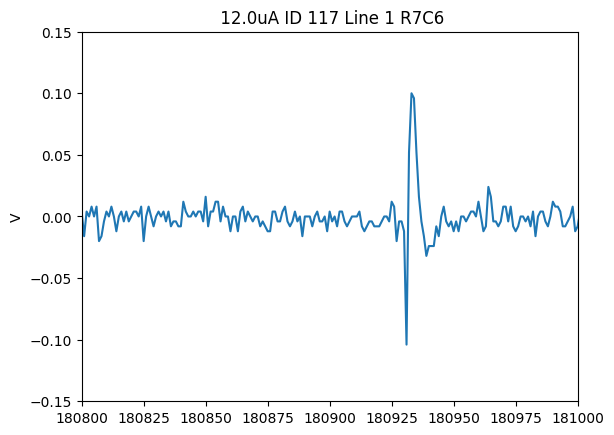

In [684]:
data = load_by_id(117).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

plt.plot(trace)
plt.title(f' {current*1e6}uA ID {117} {device_name_1}')
plt.xlabel('Samples')
plt.ylabel('V')
plt.xlim([180.8e3, 181e3])
plt.ylim([-0.15, 0.15])

In [691]:
data = load_by_id(117).get_parameter_data()
time_axis117 = data['time_axis']['time_axis']
h_samples117 = data['h_samples']['h_samples']

In [692]:
h_samples117

array([1250000.])

In [675]:
trace

array([-0.004,  0.004,  0.008, ...,  0.   ,  0.004,  0.   ],
      shape=(1000000,))

In [674]:
time_axis

array([-0.0016    , -0.00159997, -0.00159994, ...,  0.0383999 ,
        0.03839994,  0.03839997], shape=(1250000,))

Testing time axis conversion

In [689]:
h_samples

1250000

In [686]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/h_samplerate
time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t

In [688]:
time_axis

array([-0.004     , -0.00399992, -0.00399984, ...,  0.09599976,
        0.09599984,  0.09599992], shape=(1250000,))

I am guessing that because the trace is long the data transfer timed out and so the time axis is longer than the trace. THe numbers on the time axis look right

In [695]:
############################ LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)
print(f'Power 90% port: {pm120.power()}')

Laser enable status: True
Power 90% port: 0.00447676796


In [707]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


In [713]:
p_att.write('INST:SEL CH2')

In [714]:
p_att.write('SOURCE:OUTP:ENAB ON')

In [717]:
p_att.write(f'SOURCE:VOLT 3')

In [716]:
############################ LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)
print(f'Power 90% port: {pm120.power()}')

Laser enable status: True
Power 90% port: 0.00447332347


In [718]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


In [719]:
p_att.write(f'SOURCE:VOLT 2.5')

In [720]:
############################ LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)
print(f'Power 90% port: {pm120.power()}')

Laser enable status: True
Power 90% port: 0.0044881464


In [723]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


The laser does have an impact just not at high attenuation 

In [726]:
current = yoko.current()
# Thresholds from ID 12 
if current > 13e-6:
    threshold1 = -330e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 11e-6:
    threshold1 = -276e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 9e-6:
    threshold1 = -237e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 7e-6:
    threshold1 = -177e-3 # in volts
    threshold2 = -50e-3 # in volt


else:
    threshold1 = -126e-3 # in volts
    threshold2 = -50e-3 # in volt


# Set thresholds  
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')


In [728]:
# Set horizontal scale to 10ms per division 
MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3

# Set horizontal scale position to 0 
MS.write('HORizontal:POSition 0') 

Copy sweep code from ID 93 

In [729]:
meas = Measurement()
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1 # s <-  
# set current near transition based on ID 12 
current = 12e-6
device = device_name_1
voltages = np.arange(3.4, 7.05, 0.05) # <- sweep parameter is voltage applied to attnuator

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    # Set attenuator to 5V
    p_att.write(f'VOLT 5')
    time.sleep(5)
    
    ############################ LASER ON ############################ 
    laser.enable(True)
    print(f'Laser enable status: {laser.enable()}')
    time.sleep(10)
    print(f'Power 90% port: {pm120.power()}')
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    # Set current
    yoko.current(current)
    time.sleep(1)

    for v_attenuator in voltages[::-1]: # <- sweep voltage applied to attenuator
        
        p_att.write(f'VOLT {v_attenuator}')
        print(f'Starting V={v_attenuator}')
        time.sleep(1)
          

        # Thresholds from ID 12 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt
            

        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2), 
                             ("v_attenuator", v_attenuator))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Starting experimental run with id: 118. 
118
Laser enable status: True
Power 90% port: 0.00447186176
Starting V=6.999999999999988
This acquisition will take 10s
11 38
Starting V=6.949999999999987
This acquisition will take 10s
11 39
Starting V=6.899999999999988
This acquisition will take 10s
11 39
Starting V=6.849999999999987
This acquisition will take 10s
11 39
Starting V=6.799999999999988
This acquisition will take 10s
11 39
Starting V=6.749999999999988
This acquisition will take 10s
11 40
Starting V=6.699999999999989
This acquisition will take 10s
11 40
Starting V=6.649999999999988
This acquisition will take 10s
11 40
Starting V=6.599999999999989
This acquisition will take 10s
11 40
Starting V=6.549999999999988
This acquisition will take 10s
11 41
Starting V=6.499999999999989
This acquisition will take 10s
11 41
Starting V=6.449999999999989
This acquisition will take 10s
11 41
Starting V=6.39999999999999
This acquisition will take 10s
11 42
Starting V=6.349999999999989
This acquisit

In [730]:
laser.enable()

False

Reviewing thresholds

The peaks are really very different lengths. The results suggest somewhere in the middle. 

In [731]:
current = 6e-6
yoko.current(current)


# Thresholds from ID 12 
if current > 13e-6:
    threshold1 = -330e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 11e-6:
    threshold1 = -276e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 9e-6:
    threshold1 = -237e-3 # in volts
    threshold2 = -50e-3 # in volt


elif current > 7e-6:
    threshold1 = -177e-3 # in volts
    threshold2 = -50e-3 # in volt


else:
    threshold1 = -126e-3 # in volts
    threshold2 = -50e-3 # in volt

Check dark counts for 12uA, exact current conditions

Take same counting code from ID 118, remove laser on and off. Same connection. 

In [732]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

print('Finished!')

Laser enable status: False
Finished!


In [ ]:
meas = Measurement()
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("CR1", label="cps")
meas.register_custom_parameter("CR2", label="cps")
meas.register_custom_parameter("n_captures")
meas.register_custom_parameter("v_attenuator", label="V")

n_captures = 10
bin_length = 1 # s <-  
# set current near transition based on ID 12 
current = 12e-6
device = device_name_1

with meas.run() as datasaver:
    print(datasaver.run_id)
    
    # save device name 
    datasaver.dataset.add_metadata("device", device)
    
    
    
    # Set horizontal scale to 10ms per division 
    MS.write('HORizontal:MODe:SCAle 10e-3') # sets scale in seconds per division, max appears to be 10e-3
    
    # Set horizontal scale position to 0 
    MS.write('HORizontal:POSition 0') 
    
    time.sleep(2)
    
    # Calculate time trace 
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/h_samplerate
    time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t
    trace_time = time_axis[-1] - time_axis[0] # time in trace
    
    # Set current
    yoko.current(current)
    time.sleep(1)

    for v_attenuator in voltages[::-1]: # <- sweep voltage applied to attenuator
        
        p_att.write(f'VOLT {v_attenuator}')
        print(f'Starting V={v_attenuator}')
        time.sleep(1)
          

        # Thresholds from ID 12 
        if current > 13e-6:
            threshold1 = -330e-3 # in volts
            threshold2 = -50e-3 # in volt
  

        elif current > 11e-6:
            threshold1 = -276e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 9e-6:
            threshold1 = -237e-3 # in volts
            threshold2 = -50e-3 # in volt


        elif current > 7e-6:
            threshold1 = -177e-3 # in volts
            threshold2 = -50e-3 # in volt


        else:
            threshold1 = -126e-3 # in volts
            threshold2 = -50e-3 # in volt
            

        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        MS.write("SEARCH:SEARCH1:STATE 0")
        MS.write("SEARCH:SEARCH1:STATE 1")
        MS.write("SEARCH:SEARCH2:STATE 0")
        MS.write("SEARCH:SEARCH2:STATE 1")

        start = time.perf_counter()
        print(f'This acquisition will take {n_captures*bin_length}s')
        print(datetime.datetime.now().hour,  datetime.datetime.now().minute)

        counts1= []
        counts2= []

        
        for i in range(n_captures):
            time.sleep(bin_length)

            # Extract counts 
            count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
            count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

            counts1.append(count1)
            counts2.append(count2)

            
        # calculate total counts 
        total_counts1 = sum(counts1)
        total_counts2 = sum(counts2)
        
        # total time in measurement 
        meas_time = n_captures*trace_time
        
        # dark count rate calculation
        CR1 = total_counts1/meas_time
        CR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             (dmm.volt, dmm.volt()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("CR1", CR1), 
                             ("CR2", CR2), 
                             ("v_attenuator", v_attenuator))


In [733]:
samplerate

625000000.0

In [734]:
trace_time

np.float64(0.0019999984)

The first time trying to calculate time axis length from code: 

In [735]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/samplerate
time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t
trace_time = time_axis[-1] - time_axis[0] # time in trace

In [736]:
trace_time

np.float64(0.0019999984)

In [738]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/h_samplerate
time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t
trace_time = time_axis[-1] - time_axis[0] # time in trace

In [740]:
trace_time*1e3 # in ms -> this is correct 

np.float64(99.99992)

I can probably correct the numbers

# 7/4/26

In [742]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
h_samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/h_samplerate
time_axis = np.arange(0, h_samples, 1)/h_samplerate - h_centre_t
trace_time = time_axis[-1] - time_axis[0] # time in trace

In [743]:
h_samplerate

12500000.0

In [744]:
h_samples

1250000

In [745]:
MS.ask('CH1?') # vertical group commands

'"N/A";"N/A";DEFAULT;0.0E+0;0.0E+0;0.0E+0;0.0E+0;"1X";"N/A";0;0;"";"V";PASSED;50.0000;PASSED;10.0000E+36;"";DEFAULT;1.0000;10.0000E+36;AUTO;500.0000E+6;50.0000;656.2500E+6;343.7500E+6;0;1.0;0.0E+0;"A";0;DC;0;1.0000E+9;1.0000E+9;"2e+07,2.5e+08,1e+09";FLATNESS;0;100.0000E-3;1.0000;0.0E+0;0.0E+0;0.0E+0;0;0.0E+0;DEFAULT;0.0E+0;0.0E+0;"";"";14;"Frutiger LT Std 55 Roman";0;0;0;45.0000;0.0E+0;50.0000'

In [749]:
from qcodes.parameters import Parameter
from qcodes.station import Station
from qcodes.instrument import Instrument

In [764]:
station_test = Station(config_file='test.yaml')

FileNotFoundError: None

In [748]:
station.add_component(MS)

[MS(MSO5)] Snapshot: Could not update parameter: threshold
[MS(MSO5)] Snapshot: Could not update parameter: threshold2


'MS'

In [750]:
station.components

{'MS': <MSO5: MS>}

So add a snapshot at every run? 

In [763]:
station.snapshot()['instruments']

{'MS': {'functions': {'auto_counter': {}},
  'submodules': {'channels': {'snapshotable': False,
    '__class__': 'qcodes.instrument.channel.ChannelList'},
   'trigger_channels': {'snapshotable': False,
    '__class__': 'qcodes.instrument.channel.ChannelList'},
   'waveform': {'functions': {},
    'submodules': {},
    'parameters': {'y_multiplication': {'__class__': 'qcodes.parameters.parameter.Parameter',
      'full_name': 'MS_waveform_y_multiplication',
      'value': 0.004,
      'raw_value': '4.0000E-3',
      'ts': '2026-04-07 12:12:24',
      'unit': '',
      'label': 'y_multiplication',
      'instrument': 'MSO5.MSO5waveform',
      'instrument_name': 'MS_waveform',
      'name': 'y_multiplication',
      'validators': [],
      'post_delay': 0,
      'inter_delay': 0},
     'y_offset': {'__class__': 'qcodes.parameters.parameter.Parameter',
      'full_name': 'MS_waveform_y_offset',
      'value': 0.004,
      'raw_value': '4.0000E-3',
      'ts': '2026-04-07 12:12:24',
      

In [766]:
MS.snapshot()

{'functions': {'auto_counter': {}},
 'submodules': {'channels': {'snapshotable': False,
   '__class__': 'qcodes.instrument.channel.ChannelList'},
  'trigger_channels': {'snapshotable': False,
   '__class__': 'qcodes.instrument.channel.ChannelList'},
  'waveform': {'functions': {},
   'submodules': {},
   'parameters': {'y_multiplication': {'__class__': 'qcodes.parameters.parameter.Parameter',
     'full_name': 'MS_waveform_y_multiplication',
     'value': 0.004,
     'raw_value': '4.0000E-3',
     'ts': '2026-04-07 12:12:24',
     'unit': '',
     'label': 'y_multiplication',
     'instrument': 'MSO5.MSO5waveform',
     'instrument_name': 'MS_waveform',
     'name': 'y_multiplication',
     'validators': [],
     'post_delay': 0,
     'inter_delay': 0},
    'y_offset': {'__class__': 'qcodes.parameters.parameter.Parameter',
     'full_name': 'MS_waveform_y_offset',
     'value': 0.004,
     'raw_value': '4.0000E-3',
     'ts': '2026-04-07 12:12:24',
     'unit': '',
     'label': 'y_off

In [768]:
import qcodes.configuration

In [772]:
qcodes.configuration.Config().save_to_cwd()

In [778]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)

In [779]:
dmm

<Keysight34410A: dmm>

In [ ]:
station = Station(config_file="friesland.yaml")
p_att = station.load_instrument("dmm_keithley", revive_instance=True)

In [780]:
station = Station(config_file="friesland.yaml")
p_att = station.load_instrument("dmm_keithley", revive_instance=True)

TypeError: 'module' object is not callable

In [795]:
p_att.close()

In [1]:
laser.close()

NameError: name 'laser' is not defined

# 8/4/26

In [2]:
from MSO5 import MSO5
# MS.close()
MS = MSO5('MS', address='TCPIP0::10.196.52.96::inst0::INSTR', channels_n =4)

In [3]:
MS.waveform_data()

VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.